In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import os
from collections import defaultdict
from sklearn.metrics.pairwise import haversine_distances
from enum import Enum
from matplotlib.lines import Line2D
from tqdm import tqdm
import geopandas as gpd
import geodatasets
from collections import Counter

# Data Handling and Preprocessing

In [59]:
def import_data(data : str) -> pd.DataFrame:
    if not os.path.exists(data):
        print("Error: file does not exist.")
        return None
    df = pd.read_csv(data)
    return df

In [60]:
def preprocess_data (df: pd.DataFrame, min_population : float =1e5) -> pd.DataFrame:
    df = df.dropna()
    df = df[df['country'] == 'India']
    df = df[df['population'] >= min_population]
    df = df[df['lng'].between(65, 100) & df['lat'].between(5, 40)]
    df = df.drop_duplicates(subset=['city'])
    df = df[['city', 'population', 'country', 'lat', 'lng']].copy()
    df = df.reset_index(drop=True)
    df.insert(0, 'city_id', range(len(df)))
    
    return df

In [61]:
data_path = "data/indiacities.csv"

df = import_data(data_path)
df = preprocess_data(df, 1e5)
df.to_csv("data/cities_data.csv", index = False)

In [62]:
def plot_cities(df: pd.DataFrame, airway_df: pd.DataFrame, railway_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5, 5))
    

    airway_cities = set(airway_df['city'].unique())
    railway_cities = set(railway_df['city'].unique())
    
    # Categorize each city
    def get_category(city):
        in_airway = city in airway_cities
        in_railway = city in railway_cities
        
        if in_airway and in_railway:
            return 'both'
        elif in_railway:
            return 'railway'
        elif in_airway:
            return 'airway'
        else:
            return 'none'
    
    df['transport_type'] = df["city"].apply(get_category)
    
    # Plot each category with different colors
    colors = {'none': 'steelblue', 'railway': 'green', 'airway': 'red', 'both': 'purple'}
    labels = {'none': 'Road only', 'railway': 'Road+Railway', 'airway': 'Road+Airway', 'both': 'All modes'}
    
    for category in ['none', 'railway', 'airway', 'both']:
        mask = df['transport_type'] == category
        ax.scatter(df[mask]['lng'], df[mask]['lat'], s=10, alpha=0.5, 
                  c=colors[category], label=labels[category])
    
    ax.set_xlim(65, 100)
    ax.set_ylim(5, 40)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig('analysis/cities_graph.png', dpi=200)
    plt.show()

# Cost Calculations

### Constants

In [63]:
class TransportMode(Enum):
    ROAD = "road"
    RAIL = "rail"
    AIR = "air"

In [64]:
## Cost of travel when transporting freight by different modes (INR/tonne-km)
TRAVEL_COSTS_TONNE_KM = {
    TransportMode.ROAD: 3.6,
    TransportMode.RAIL: 1.6,
    TransportMode.AIR: 18,
}

## CO2 emissions when transporting freight by different modes (gm CO2/tonne-km)
CO2_EMISSIONS_TONNE_KM = {
    TransportMode.ROAD: 1010,
    TransportMode.RAIL: 11.5,
    TransportMode.AIR: 610,
}

TRAVEL_SPEEDS = {
    TransportMode.ROAD: 30,
    TransportMode.RAIL: 35,
    TransportMode.AIR: 450,
}

In [65]:
COST_OF_CARBON_KG = 4.42    # Median carbon shadow price in major corporations $49/tonne = INR 4.42/kg CO2
CONSUMPTION_RATE = 2.78   # Average parcels per person
AVG_WEIGHT_PER_UNIT_KG = 1.5 # Typical Amazon parcel avg weight
TIME_VALUE_KG_HOUR = 2.0
AOV_INDIA = 9600.0
CARRYING_RATE = 0.20
CARRYING_COST_PARCEL_HOUR = AOV_INDIA*CARRYING_RATE/8760
TIME_VALUE_KG_HOUR = CARRYING_COST_PARCEL_HOUR*AVG_WEIGHT_PER_UNIT_KG
SHIPMENT_WEIGHT_PER_PERSON = CONSUMPTION_RATE*AVG_WEIGHT_PER_UNIT_KG
WAREHOUSE_LAND_AREA = 2.5e5
LAND_RENT_SQFT_YEAR = 24*12
OPEX_RATIO = 0.5
WAREHOUSE_COST = WAREHOUSE_LAND_AREA*LAND_RENT_SQFT_YEAR*(1+OPEX_RATIO)

### Cost Functions

In [66]:
def get_distance_matrix(df: pd.DataFrame) -> pd.DataFrame:

    lat = df["lat"].to_numpy()
    lng = df["lng"].to_numpy()
    cities = df["city"].to_numpy()
    
    coords = np.column_stack([np.radians(lat), np.radians(lng)])
    d_mat = haversine_distances(coords)
    
    # Convert radians to km (Earth radius = 6371 km)
    d_mat = d_mat * 6371

    return pd.DataFrame(d_mat, index=cities, columns=cities)

In [67]:
def calc_fuel_cost_matrix(dist_matrix: np.ndarray, mode: TransportMode) -> np.ndarray:
    weight_tonnes = SHIPMENT_WEIGHT_PER_PERSON/1000
    lc = TRAVEL_COSTS_TONNE_KM[mode]

    if mode == TransportMode.AIR:
        a, k = 10000.0, 0.005
        return weight_tonnes * (a * (1-np.exp(-k*dist_matrix)) + lc*dist_matrix) * (1+ 0.5*(dist_matrix>1200))
    else:
        return lc*weight_tonnes*dist_matrix

In [68]:
def calc_carbon_cost_matrix(dist_matrix: np.ndarray, mode: TransportMode) -> np.ndarray:
    emissions_kg = (CO2_EMISSIONS_TONNE_KM[mode] * (SHIPMENT_WEIGHT_PER_PERSON/1000) * dist_matrix) / 1000
    return emissions_kg * COST_OF_CARBON_KG

In [69]:
def calc_time_cost_matrix(dist_matrix: np.ndarray, mode: TransportMode) -> np.ndarray:
    speeds = {
        TransportMode.AIR: 532.0,
        TransportMode.RAIL: 25.0,
        TransportMode.ROAD: 30.0,
    }
    hours = dist_matrix/speeds[mode]
    return hours*TIME_VALUE_KG_HOUR*SHIPMENT_WEIGHT_PER_PERSON

In [142]:
def weighted_cost_matrix(fuel_m, carbon_m, time_m, weights: dict) -> np.ndarray:
    wf, wc, wt = weights['fuel'], weights['carbon'], weights['time']
    total = wf+wc+wt
    if total == 0:
        return 0
    wf = wf/total
    wc = wc/total
    wt = wt/total
    return wf*fuel_m+wc*carbon_m+wt*time_m

In [71]:
def get_direct_transport_cost_matrix(df: pd.DataFrame,
                         air_df: pd.DataFrame,
                         rail_df: pd.DataFrame,
                         distance_matrix: pd.DataFrame,
                         cost_weights: dict) -> pd.DataFrame:
    cities = df["city"].values
    n = len(cities)

    dist_np = distance_matrix.loc[cities, cities].to_numpy()

    road_fuel   = calc_fuel_cost_matrix(dist_np, TransportMode.ROAD)
    road_carbon = calc_carbon_cost_matrix(dist_np, TransportMode.ROAD)
    road_time   = calc_time_cost_matrix(dist_np, TransportMode.ROAD)
    road_total  = weighted_cost_matrix(road_fuel, road_carbon, road_time, cost_weights)

    air_fuel    = calc_fuel_cost_matrix(dist_np, TransportMode.AIR)
    air_carbon  = calc_carbon_cost_matrix(dist_np, TransportMode.AIR)
    air_time    = calc_time_cost_matrix(dist_np, TransportMode.AIR)
    air_total   = weighted_cost_matrix(air_fuel, air_carbon, air_time, cost_weights)

    rail_fuel   = calc_fuel_cost_matrix(dist_np, TransportMode.RAIL)
    rail_carbon = calc_carbon_cost_matrix(dist_np, TransportMode.RAIL)
    rail_time   = calc_time_cost_matrix(dist_np, TransportMode.RAIL)
    rail_total  = weighted_cost_matrix(rail_fuel, rail_carbon, rail_time, cost_weights)

    air_cities  = set(air_df["city"].values)
    rail_cities = set(rail_df["city"].values)
    port_blair  = "Port Blair"

    has_air  = np.array([c in air_cities  for c in cities], dtype=bool)  # (n,)
    has_rail = np.array([c in rail_cities for c in cities], dtype=bool)  # (n,)
    is_pb    = np.array([c == port_blair  for c in cities], dtype=bool)  # (n,)

    air_avail  = np.outer(has_air,  has_air)   # (n, n)
    rail_avail = np.outer(has_rail, has_rail)  # (n, n)

    pb_mask = np.outer(is_pb, np.ones(n, bool)) | np.outer(np.ones(n, bool), is_pb)
    road_total_masked = np.where(pb_mask, np.inf, road_total)

    best_total   = road_total_masked.copy()
    best_fuel    = np.where(pb_mask, np.inf, road_fuel)
    best_carbon  = np.where(pb_mask, np.inf, road_carbon)
    best_time    = np.where(pb_mask, np.inf, road_time)
    best_mode    = np.where(pb_mask, 'none', 'road')

    air_better  = air_avail & (air_total < best_total)
    best_total  = np.where(air_better, air_total,  best_total)
    best_fuel   = np.where(air_better, air_fuel,   best_fuel)
    best_carbon = np.where(air_better, air_carbon, best_carbon)
    best_time   = np.where(air_better, air_time,   best_time)
    best_mode   = np.where(air_better, 'air',      best_mode)

    rail_better = rail_avail & (rail_total < best_total)
    best_total  = np.where(rail_better, rail_total,  best_total)
    best_fuel   = np.where(rail_better, rail_fuel,   best_fuel)
    best_carbon = np.where(rail_better, rail_carbon, best_carbon)
    best_time   = np.where(rail_better, rail_time,   best_time)
    best_mode   = np.where(rail_better, 'rail',      best_mode)

    mode_map = {
        'road': TransportMode.ROAD,
        'air':  TransportMode.AIR,
        'rail': TransportMode.RAIL,
    }

    data = {}
    print("Step 2/4: Building transport cost matrix...")
    for i, src in enumerate(cities):
        row_data = {}
        for j, dst in enumerate(cities):
            if src == dst:
                row_data[dst] = (0, {'fuel': 0, 'carbon': 0, 'time': 0,
                                     'mode': 'no transport'})
            elif best_total[i, j] == np.inf:
                row_data[dst] = (float('inf'), {'fuel': np.inf, 'carbon': np.inf,
                                                'time': np.inf, 'mode': 'not known'})
            else:
                mode_str = best_mode[i, j]
                comp = {
                    'fuel':   float(best_fuel[i, j]),
                    'carbon': float(best_carbon[i, j]),
                    'time':   float(best_time[i, j]),
                    'mode':   mode_map.get(mode_str, mode_str),
                }
                row_data[dst] = (float(best_total[i, j]), comp)
        data[src] = row_data

    return pd.DataFrame(data)

In [72]:
def floyd_warshall(
    transport_costs: pd.DataFrame,
    cities: np.ndarray,
    eps: float = 1e-5
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    dist_dict = {}
    components_dict = {}
    next_node_dict = {}
    hops = {}

    # Initialization
    for i in cities:
        dist_dict[i] = {}
        components_dict[i] = {}
        next_node_dict[i] = {}
        hops[i] = {}

        for j in cities:
            if i == j:
                dist_dict[i][j] = 0.0
                hops[i][j] = 0
                next_node_dict[i][j] = None
                components_dict[i][j] = {
                    'fuel': 0.0,
                    'carbon': 0.0,
                    'time': 0.0,
                    'mode': 'no transport'
                }

            else:
                cost, components = transport_costs[i][j]
                dist_dict[i][j] = float(cost)
                hops[i][j] = 1
                next_node_dict[i][j] = j
                components_dict[i][j] = components.copy()

    # Floyd Warshall
    for k in tqdm(cities, desc="Step 3/4: Running Floyd Warshall algorithm..."):
        for i in cities:
            if dist_dict[i][k] == float('inf'):
                continue
            for j in cities:
                if dist_dict[k][j] == float('inf'):
                    continue

                new_cost = dist_dict[i][k] + dist_dict[k][j]
                old_cost = dist_dict[i][j]

                new_hops = hops[i][k] + hops[k][j]
                old_hops = hops[i][j]

                if (
                    new_cost < old_cost - eps
                    or (abs(new_cost - old_cost) <= eps and new_hops < old_hops)
                ):
                    dist_dict[i][j] = new_cost
                    hops[i][j] = new_hops
                    next_node_dict[i][j] = next_node_dict[i][k]
                    components_dict[i][j] = {
                        'fuel': components_dict[i][k]['fuel'] + components_dict[k][j]['fuel'],
                        'carbon': components_dict[i][k]['carbon'] + components_dict[k][j]['carbon'],
                        'time': components_dict[i][k]['time'] + components_dict[k][j]['time'],
                        'mode': 'mixed'
                    }

    dist_df = pd.DataFrame(dist_dict)
    components_df = pd.DataFrame(components_dict)
    next_node_df = pd.DataFrame(next_node_dict)

    return dist_df, components_df, next_node_df

In [73]:
def floyd_warshall(transport_costs: pd.DataFrame,
                   cities: np.ndarray,
                   eps: float = 1e-5) -> tuple [pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    n = len(cities)
    city_to_idx = {c: i for i, c in enumerate(cities)}

    dist = np.full((n,n), np.inf)
    hops = np.zeros((n, n), dtype = np.int32)
    next_idx = np.full((n, n), -1, dtype = np.int32)
    fuel = np.zeros((n, n))
    carbon = np.zeros((n, n))
    time_arr = np.zeros((n, n))

    np.fill_diagonal(dist, 0.0)

    for i, src in enumerate(cities):
        for j, dst in enumerate(cities):
            if i == j:
                continue
            cost, comp = transport_costs[src][dst]
            dist[i,j] = float(cost)
            hops[i, j] = 1
            next_idx[i, j] = j
            fuel[i, j] = comp['fuel']
            carbon[i, j] = comp['carbon']
            time_arr[i, j] = comp['time']
    print("Step 3/4: Running Floyd Warshall algorithm... ")
    for k in range(n):
        new_cost = dist[:, k:k+1]+dist[k:k+1, :]
        new_hops = hops[:, k:k+1]+hops[k:k+1,:]
        better_cost = new_cost < (dist-eps)
        equal_fewer = (np.abs(new_cost-dist) <= eps) & (new_hops < hops)
        update = better_cost | equal_fewer

        dist = np.where(update, new_cost, dist)
        hops = np.where(update, new_hops, hops)
        next_idx = np.where(update, next_idx[:, k:k+1], next_idx)

        fuel = np.where(update, fuel[:, k:k+1]     + fuel[k:k+1, :],     fuel)
        carbon = np.where(update, carbon[:, k:k+1]   + carbon[k:k+1, :],   carbon)
        time_arr = np.where(update, time_arr[:, k:k+1] + time_arr[k:k+1, :], time_arr)

    dist_dict = {}
    components_dict = {}
    next_node_dict = {}

    for i, src in enumerate(cities):
        dist_dict[src] = {}
        components_dict[src] = {}
        next_node_dict[src] = {}

        for j, dst in enumerate(cities):
            dist_dict[src][dst] = dist[i, j]
            nxt_i = next_idx[i, j]
            next_node_dict[src][dst] = cities[nxt_i] if nxt_i >= 0 else None

            if i == j:
                mode_label = 'no transport'
            elif hops[i, j] > 1:
                mode_label = 'mixed'
            else:
                _, orig_comp = transport_costs[src][dst]
                mode_label = orig_comp['mode']

            components_dict[src][dst] = {
                'fuel':   fuel[i, j],
                'carbon': carbon[i, j],
                'time':   time_arr[i, j],
                'mode':   mode_label,
            }

    dist_df = pd.DataFrame(dist_dict)
    components_df = pd.DataFrame(components_dict)
    next_node_df = pd.DataFrame(next_node_dict)

    return dist_df, components_df, next_node_df

### Network Analysis

In [74]:
def analyse_network(df: pd.DataFrame,
                    air_df:pd.DataFrame,
                    rail_df: pd.DataFrame,
                    weights: dict) -> tuple:
    print("Step 1/4: Calculating physical distance matrix...")
    dist_matrix = get_distance_matrix(df)

    direct_cost_matrix = get_direct_transport_cost_matrix(
        df=df,
        air_df=air_df,
        rail_df=rail_df,
        distance_matrix=dist_matrix,
        cost_weights=weights
    )
    cities = df["city"].values
    return floyd_warshall(transport_costs=direct_cost_matrix, cities=cities)

In [75]:
def assign_fcs(df: pd.DataFrame,
               fc_df: pd.DataFrame,
               transport_costs: pd.DataFrame,
               cost_components: pd.DataFrame) -> pd.DataFrame:

    hub_to_city_costs = transport_costs.loc[:, fc_df['city'].values]
   
    fca = hub_to_city_costs.idxmin(axis = 1).to_frame(name = 'fc')
    # analyze_and_visualize_fc_network(df, fc_df, assign_df, transport_components)
    return fca

In [119]:
def calc_network_cost(df: pd.DataFrame,
                      fc_df: pd.DataFrame,
                      fc_sol: np.ndarray,
                      transport_costs: pd.DataFrame,
                      cost_components: pd.DataFrame,
                      weights: dict,
                      warehouse_costs: float = WAREHOUSE_COST) -> float:
    if np.sum(fc_sol) == 0:
        return float('inf'), None
    fc_cities = pd.DataFrame(fc_df['city'].values[fc_sol == 1], columns = ['city'])
    assigned_fcs = assign_fcs(df, fc_cities, transport_costs, cost_components)
    transport_cost_total = 0
    assigned = assigned_fcs.join(df.set_index('city')['population'], how='left')
    cost_per_person = transport_costs.to_numpy()[
        transport_costs.index.get_indexer(assigned.index),
        transport_costs.columns.get_indexer(assigned['fc'])
    ]
    transport_cost_total = (cost_per_person * assigned['population'].to_numpy()).sum()
    # print(f"Transport cost: {transport_cost_total}")
    fixed_cost = warehouse_costs* np.sum(fc_sol)
    fixed_weight = weights['fixed']/sum(weights.values())
    # print(f"Fixed cost: {fixed_cost}")
    cost = transport_cost_total+fixed_cost*fixed_weight
    return cost, assigned_fcs
    

In [136]:
def calc_network_cost_batch(df: pd.DataFrame,
                      solutions: np.ndarray,
                      transport_costs: pd.DataFrame,
                      cost_components: pd.DataFrame,
                      fixed_weight: float,
                      warehouse_cost: float = WAREHOUSE_COST) -> float:
    n_sol = solutions.shape[0]
    costs = np.zeros(n_sol)
    pop_array = df['population'].values
    transport_matrix = transport_costs.values
    for i in range(n_sol):
        sol = solutions[i]
        n_warehouses = sol.sum()
        if n_warehouses == 0:
            costs[i] = np.inf
            continue
        fc_idx = np.where(sol == 1)[0]
        costs_to_fcs = transport_matrix[:, fc_idx]
        min_costs = costs_to_fcs.min(axis = 1)
        transport_cost = (min_costs * pop_array).sum()
        fixed_cost = n_warehouses * warehouse_cost
        costs[i] = transport_cost+fixed_cost*fixed_weight

    return costs

In [78]:
def calc_network_cost_components(df: pd.DataFrame,
                                 sol: np.ndarray,
                                 transport_costs: pd.DataFrame,
                                 cost_components: pd.DataFrame,
                                 fc_df: pd.DataFrame | None = None) -> np.ndarray:
    if fc_df is None:
        fc_df = df[['city']]
    n_dcs = np.sum(sol)
    fc_cities = pd.DataFrame(fc_df['city'].values[sol == 1], columns=['city'])
    fc_assign = assign_fcs(df, fc_cities, transport_costs, cost_components)

    pop_lookup = df.set_index('city')['population']
    fc_assign['population'] = fc_assign.index.map(pop_lookup)
    mask = fc_assign.index != fc_assign['fc']
    fc_sub = fc_assign[mask].copy()

    if fc_sub.empty:
        return np.array([0.0, 0.0, 0.0, n_dcs * WAREHOUSE_COST])

    cost_dicts = pd.Series(
        [cost_components.at[city, fc] for city, fc in zip(fc_sub.index, fc_sub['fc'])],
        index=fc_sub.index
    )

    cost_df = pd.json_normalize(cost_dicts)
    cost_df.index = fc_sub.index

    pop = fc_sub.index.map(pop_lookup)
    result = cost_df[['fuel', 'carbon', 'time']].multiply(pop.values, axis=0).sum()
    return np.array([result['fuel'], result['carbon'], result['time'], n_dcs * WAREHOUSE_COST])

# Genetic Optimization Algorithm

In [79]:
def init_pop(sol_size: int, count: int) -> np.ndarray:
    pop = np.random.binomial(1, 0.5, size=(count, sol_size))
    
    all_zeros = pop.sum(axis=1) == 0
    
    if all_zeros.any():
        zero_row_indices = np.where(all_zeros)[0]
        random_cols = np.random.randint(0, sol_size, size=len(zero_row_indices))
        pop[zero_row_indices, random_cols] = 1

    return pop

In [80]:
def crossover(generation_size: int,
              pop_size: int,
              repro_size: int,
              current_gen: np.ndarray,
              scores: np.ndarray) -> np.ndarray:

    crossover_size = 2*generation_size-repro_size
    crossover_gen = np.zeros((crossover_size, pop_size))

    for i in range(0, crossover_size, 2):
        idx1 = tournament_pick(scores, k=2)
        idx2 = tournament_pick(scores, k=2)

        while idx2 == idx1:
            idx2 = tournament_pick(scores, k=2)

        p1 = current_gen[idx1, :]
        p2 = current_gen[idx2, :]

        point = np.random.randint(1, pop_size)

        child1 = np.concatenate([p1[:point], p2[point:]])
        child2 = np.concatenate([p2[:point], p1[point:]])

        crossover_gen[i, :] = child1
        crossover_gen[i+1, :] = child2
    return crossover_gen

In [81]:
def mutation(generation: np.ndarray,
             mutation_rate_pop: float,
             mutation_rate_bit: float) -> np.ndarray:
    row_mask = np.random.rand(generation.shape[0]) < mutation_rate_pop
    bit_mask = np.random.rand(*generation.shape) < mutation_rate_bit
    flip_mask = row_mask[:, np.newaxis] & bit_mask
    generation[flip_mask] = 1-generation[flip_mask]
    return generation

In [82]:
def tournament_pick(scores, k=2):
    scores = np.asarray(scores)
    finite_mask = np.isfinite(scores)
    if not np.any(finite_mask):
        return np.random.randint(0, len(scores))
    valid_indices = np.where(finite_mask)[0]
    k = min(k, len(valid_indices))
    idx = np.random.choice(valid_indices, size=k, replace=True)
    return idx[np.argmin(scores[idx])]

In [132]:
def genetic_algorithm(generation_size: int,
                      reproduction_rate: float,
                      mutation_rate_pop: float,
                      mutation_rate_bit: float,
                      num_generations: int,
                      df: pd.DataFrame,
                      transport_costs: pd.DataFrame,
                      cost_components: pd.DataFrame,
                      weights: dict,
                      fc_df: pd.DataFrame | None = None,
                      progress_bar: bool = True,
                      
                     ) -> dict:

    if fc_df is None:
        fc_df = df[['city']]

    # Generation 0
    solution_size = len(fc_df)
    num_repro = (int(generation_size*reproduction_rate)//2)*2
    fixed_weight = weights['fixed']/sum(weights.values())
    current_gen = init_pop(sol_size = solution_size, count = generation_size)
    scores = calc_network_cost_batch(df, current_gen, transport_costs, cost_components, fixed_weight)
    indices = np.argsort(scores)
    current_gen = current_gen[indices]

    best_score = float('inf')
    best_sol = []
    min_scores = []

    loop_iter = tqdm(range(num_generations),
                 desc="Step 4/4: Running genetic algorithm... ",
                 ncols=100) if progress_bar else range(num_generations)
    
    for gen in loop_iter:
        new_gen = np.zeros((2 * generation_size, solution_size))
        new_gen[:num_repro, :] = current_gen[:num_repro, :]
        new_gen[num_repro:, :] = crossover(generation_size = generation_size, pop_size = solution_size, repro_size = num_repro, current_gen = current_gen, scores = scores)
        scores = calc_network_cost_batch(df, new_gen, transport_costs, cost_components, fixed_weight)
        # np.array([calc_network_cost(df, fc_df, solution, transport_costs, cost_components)[0] for solution in new_gen])
        indices = np.argsort(scores)
        new_gen = new_gen[indices]
        scores = scores[indices]
        
        new_gen = new_gen[:generation_size, :]
        scores = scores[:generation_size]
        new_gen = mutation(new_gen, mutation_rate_pop, mutation_rate_bit)
        current_gen = new_gen
        
        if scores[0] < best_score:
            best_score = scores[0]
            best_sol = new_gen[0]
        min_scores.append(best_score)


    # plot_ga_convergence(min_scores)

    result = {
        "final_pop": best_sol,
        "min_scores": min_scores,
        "params": {
            'generation_size': generation_size,
            'reproduction_rate': reproduction_rate,
            'mutation_rate_pop': mutation_rate_pop,
            'mutation_rate_bit': mutation_rate_bit,
            'num_generations': num_generations,
            'transport_costs': transport_costs,
            'cost_components': cost_components,
        }
    }
    
    return result

# Constrained GA

In [84]:
def init_constrained_pop(generation: np.ndarray,
                         constrained: str,
                         threshold: float,
                         generation_size: int,
                         sol_size: int,
                         df: pd.DataFrame,
                         transport_costs: pd.DataFrame,
                         cost_components: pd.DataFrame) -> np.ndarray:
    attempts = 0
    max_attempts = 100
    constrain_idx = {
        'fuel': 0,
        'carbon': 1,
        'time': 2,
        'fixed': 3,
    }
    idx = constrain_idx[constrained]
    while len(generation)<generation_size and attempts < max_attempts:
        mini_batch = generation_size-len(generation)
        batch_size = mini_batch*10
        batch = init_pop(sol_size = sol_size, count = batch_size)
        scores = np.array([calc_network_cost_components(df, batch[i, :], transport_costs, cost_components)[idx] for i in range(batch_size)])

        valid_indices = np.where(scores <= threshold)[0]
        if len(valid_indices) > 0:
            valid = batch[valid_indices]
            generation.extend(valid.tolist())
        attempts += 1
    if len(generation)<generation_size:
        print(f"Warning: Could not fill population after {attempts} batch attempts. "
              f"Found {len(generation)}/{generation_size} valid candidates.")
        remainder = generation_size-len(generation)
        extras = init_pop(sol_size = sol_size, count = remainder)
        generation.extend(extras.tolist())

    return np.array(generation[:generation_size])

In [85]:
def ga_constraint(generation_size: int,
                  reproduction_rate: float,
                  mutation_rate_pop: float,
                  mutation_rate_bit: float,
                  num_generations: int,
                  df: pd.DataFrame,
                  transport_costs: pd.DataFrame,
                  cost_components: pd.DataFrame,
                  constrained: str,
                  threshold: float,
                  fc_df: pd.DataFrame | None = None) -> dict:
    
    if fc_df is None:
        fc_df = df[['city']]
    solution_size = len(fc_df)
    num_repro = (int(generation_size*reproduction_rate)//2)*2
    current_gen = init_constrained_pop(generation = np.zeros((0, solution,size), dtype = int),
                                       constrained = constrained,
                                       threshold = threshold,
                                       generation_size = generation_size,
                                       sol_size = solution_size,
                                       df = df,
                                       transport_costs = transport_costs,
                                       cost_components = cost_components)
    scores = np.array([calc_network_cost(df, fc_df, solution, transport_costs, cost_components)[0] for solution in current_gen])
    indices = np.argsort(scores)
    current_gen = current_gen[indices]

    best_score = float('inf')
    best_sol = []
    min_scores = []

    for gen in tqdm(range(num_generations), desc = "Running constrained genetic algorithm... "):
        new_gen = np.zeros((2 * generation_size, solution_size))
        new_gen[:num_repro, :] = current_gen[:num_repro, :]
        new_gen[num_repro:, :] = crossover(generation_size = generation_size, pop_size = solution_size, repro_size = num_repro, current_gen = current_gen, scores = scores)
        scores = np.array([calc_network_cost(df, fc_df, solution, transport_costs, cost_components)[0] for solution in new_gen])
        indices = np.argsort(scores)
        new_gen = new_gen[indices]
        scores = scores[indices]
        
        new_gen = new_gen[:generation_size, :]
        scores = scores[:generation_size]
        new_gen = mutation(new_gen, mutation_rate_pop, mutation_rate_bit)
        current_gen = new_gen
        
        if scores[0] < best_score:
            best_score = scores[0]
            best_sol = new_gen[0]
        min_scores.append(best_score)

# Solution Analysis

In [86]:
def plot_ga_convergence(min_scores):
    
    iterations = range(len(min_scores))
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(iterations, min_scores, label='Best Score', marker='.', linewidth=2)
    
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.title('Genetic Algorithm Convergence', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('analysis/ga_convergence.png', dpi=300, bbox_inches='tight')
    plt.show()

In [87]:
def get_path(start_city: str,
             end_city:str,
             cost_components: pd.DataFrame,
             next_node: pd.DataFrame) -> np.ndarray:
    path = []
    curr = start_city
    while not curr == end_city:
        path.append({
            'from': curr,
            'to': next_node[curr][end_city],
            'mode': cost_components[curr][next_node[curr][end_city]]['mode'],
            'cost_components': cost_components[curr][next_node[curr][end_city]],
        })
        curr = next_node[curr][end_city]
    return path

In [88]:
WORLD_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

world = gpd.read_file(WORLD_URL)
INDIA_GDF = world[world['SOVEREIGNT'] == 'India']

In [163]:
def show_dashboard(df: pd.DataFrame, 
                   ga_result: dict, 
                   transport_costs: pd.DataFrame, 
                   cost_components: pd.DataFrame, 
                   next_node: pd.DataFrame, 
                   weights: dict,
                   fc_df: pd.DataFrame | None = None):

    if fc_df is None:
        fc_df = df[['city']]
    best_genome = ga_result['final_pop']
    n_dcs = np.sum(best_genome)
    
    fc_cities = pd.DataFrame(fc_df['city'].values[best_genome == 1], columns=['city'])
    
    fc_assign = assign_fcs(df, fc_cities, transport_costs, cost_components)

    comp_fuel, comp_carbon, comp_time, comp_fixed = 0, 0, 0, n_dcs * WAREHOUSE_COST
    mode_counts = {m: 0 for m in [TransportMode.AIR, TransportMode.RAIL, TransportMode.ROAD]}
    
    network = defaultdict(set)

    for city, row in fc_assign.iterrows():
        fc = row['fc']
        if city == fc:
            continue

        comp_fuel += cost_components[fc][city]['fuel']*df[df['city'] == city]['population'].iloc[0]
        comp_carbon += cost_components[fc][city]['carbon']*df[df['city'] == city]['population'].iloc[0]
        comp_time += cost_components[fc][city]['time']*df[df['city'] == city]['population'].iloc[0]
        
        path = get_path(fc, city, cost_components, next_node)
        
        for hop in path:
            way_det = (hop['from'], hop['to'], hop['mode'])
            network[fc].add(way_det)
            
            if not hop['mode'] == 'mixed': # 'mixed' shouldn't happen on single hop, but keeping safety
                mode_counts[hop['mode']] += 1
                
    total_cost = comp_fuel + comp_carbon + comp_time + comp_fixed
    weights = {k: v/sum(weights.values()) for k,v in weights.items()}
    min_scores = ga_result['min_scores']
    
    # --- VISUALISATION ---

    ## Summary Setup
    fig = plt.figure(figsize=(20, 14))
    gs = gridspec.GridSpec(4, 2, width_ratios=[1.8, 1], height_ratios=[0.4, 1.2, 1.2, 1.2])
    fig.suptitle("Network Dashboard", fontsize=22, fontweight='bold', y=0.96)

    ## KPI Board
    ax_kpi = fig.add_subplot(gs[0, 1])
    ax_kpi.axis('off')
    kpi_text = (
    f"TOTAL NETWORK PENALTY: {'₹'+f'{(min_scores[-1])/1e7:,.1f}'+' Cr':>23}\n\n"
    f"• Open Hubs: {int(n_dcs):>33}\n"
    f"• Cost of Network: {'₹'+f'{(comp_fixed+comp_fuel)/1e7:,.1f}'+' Cr':>27}\n"
    f"   - Fixed Cost: {'₹'+f'{comp_fixed/1e7:,.1f}'+' Cr':>29}\n"
    f"   - Variable (Transport) Cost: {'₹'+f'{comp_fuel/1e7:,.1f}'+' Cr':>14}\n"
    f"• Carbon Penalty: {'₹'+f'{comp_carbon/1e7:,.1f}'+' Cr':>28}\n"
    f"• Value of Time: {'₹'+f'{comp_time/1e7:,.1f}'+' Cr':>29}"
)
    ax_kpi.text(0.05, 0.5, kpi_text, fontsize=14, va='center', fontfamily='monospace', 
                bbox=dict(boxstyle="round,pad=0.5", fc="aliceblue", ec="navy", alpha=0.8))

    ## Network Map Plot
    ax_map = fig.add_subplot(gs[:, 0])

    INDIA_GDF.plot(
        ax=ax_map,
        color="whitesmoke",
        edgecolor="black",
        linewidth=1.0,
        alpha=0.25,
        zorder=-1
    )
    # 1. Base Layer: Faint background for context
    ax_map.scatter(df['lng'], df['lat'], c='whitesmoke', s=15, alpha=0.5, zorder=0)
    
    unique_fcs = sorted(list(network.keys()))
    if len(unique_fcs) > 0:
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_fcs)))
        fc_color_map = dict(zip(unique_fcs, colors))
    else:
        fc_color_map = {}
        
    mode_styles = {
        TransportMode.AIR:  {'ls': '-',  'alpha': 0.6, 'lw': 1.0, 'curve': True},
        TransportMode.RAIL: {'ls': '--', 'alpha': 0.5, 'lw': 0.8, 'curve': False},
        TransportMode.ROAD: {'ls': ':',  'alpha': 0.4, 'lw': 0.5, 'curve': False}
    }

    # 3. Plot Cities (Colored by Assigned FC)
    for fc_name in unique_fcs:
        territory_cities = fc_assign[fc_assign['fc'] == fc_name].index
        territory_df = df[df['city'].isin(territory_cities)]
        
        c_color = fc_color_map.get(fc_name, 'grey')
        
        ax_map.scatter(territory_df['lng'], territory_df['lat'], 
                       c=[c_color], s=20, alpha=0.8, zorder=1)

    # 4. Plot Paths (Colored by FC Network)
    for fc_name, segments in network.items():
        base_color = fc_color_map.get(fc_name, 'grey')
        
        for (u, v, mode) in segments:
            p1 = (df[df['city'] == u]['lng'].iloc[0], df[df['city'] == u]['lat'].iloc[0])
            p2 = (df[df['city'] == v]['lng'].iloc[0], df[df['city'] == v]['lat'].iloc[0])
            
            style = mode_styles.get(mode, {'ls':'-', 'alpha':0.1, 'lw':0.5, 'curve':False})
            
            if style['curve']:
                arrow = patches.FancyArrowPatch(
                    p1, p2, arrowstyle='-', color=base_color, 
                    connectionstyle="arc3,rad=0.20", alpha=style['alpha'], 
                    linewidth=style['lw'], linestyle=style['ls'], zorder=2
                )
                ax_map.add_patch(arrow)
            else:
                ax_map.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                            c=base_color, alpha=style['alpha'], 
                            linewidth=style['lw'], linestyle=style['ls'], zorder=2)

    # 5. Plot FC Stars (Colored by Territory)
    for fc_name in unique_fcs:
        c_color = fc_color_map.get(fc_name, 'gold')
        
        fc_row = df[df['city'] == fc_name]
        if not fc_row.empty:
            ax_map.scatter(fc_row['lng'].iloc[0], fc_row['lat'].iloc[0], 
                           c=[c_color], s=300, marker='*', edgecolors='black', zorder=3)
            ax_map.text(fc_row['lng'].iloc[0], fc_row['lat'].iloc[0]+0.25, fc_name, 
                        fontsize=9, fontweight='bold', color='black', zorder=4)

    total_links = sum(len(segs) for segs in network.values())
    ax_map.set_title(f"Fulfillment Center Network | {total_links} Active Links", fontsize=15)
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.grid(True, alpha=0.15)

    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Air (Curved)'),
        Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Rail (Dashed)'),
        Line2D([0], [0], color='black', lw=1.5, linestyle=':', label='Road (Dotted)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=15, markeredgecolor='black', label='Hub Location')
    ]
    ax_map.legend(handles=legend_elements, loc='lower right')

    # --- Analytics Panels ---
    
    # Cost Breakdown
    ax_cost = fig.add_subplot(gs[1, 1])
    c_vals = [comp_fixed, comp_fuel, comp_carbon, comp_time]
    c_labs = ['Fixed', 'Fuel', 'Carbon', 'Time']
    colors = ['#2c3e50', '#e67e22', '#27ae60', '#c0392b']
    
    ax_cost.barh(np.arange(4), c_vals, color=colors, alpha=0.8)
    ax_cost.set_yticks(np.arange(4))
    ax_cost.set_yticklabels(c_labs)
    ax_cost.set_title('Cost Breakdown', fontsize=12, fontweight='bold')
    
    # Mode Split
    ax_mode = fig.add_subplot(gs[2, 1])
    m_vals = [mode_counts.get(TransportMode.AIR, 0), 
              mode_counts.get(TransportMode.RAIL, 0), 
              mode_counts.get(TransportMode.ROAD, 0)]
    
    if sum(m_vals) > 0:
        ax_mode.pie(m_vals, labels=['Air', 'Rail', 'Road'], autopct='%1.1f%%', 
                    colors=['red', 'blue', 'grey'], startangle=90, explode=(0.05, 0, 0))
        ax_mode.add_artist(plt.Circle((0,0),0.70,fc='white'))
    ax_mode.set_title("Active Link Mode Mix", fontsize=12, fontweight='bold')

    ax_conv = fig.add_subplot(gs[3, 1])
    
    
    iterations = range(len(min_scores))
    
    ax_conv.plot(iterations, min_scores, label='Best Score', marker='.', linewidth=2)
    
    ax_conv.set_xlabel('Generation', fontsize=12)
    ax_conv.set_ylabel('Cost', fontsize=12)
    ax_conv.set_title('Genetic Algorithm Convergence', fontsize=14)
    ax_conv.legend()
    ax_conv.grid(True, alpha=0.3)
    # ax_conv.savefig('analysis/ga_convergence.png', dpi=300, bbox_inches='tight')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [90]:
def plot_convergence_test(results: dict) -> None:
    """
    Two-panel figure:
      Left  — all convergence curves overlaid, with mean ± 1 std band
      Right — distribution of final scores (box + individual points)
    """
    curves        = results['curves']
    final_scores  = results['final_scores']
    best_run      = results['best_run']
    n_runs        = results['params']['n_runs']
    num_gens      = results['params']['num_generations']
    gens          = np.arange(num_gens)

    # Stack curves into matrix for stats — (n_runs, num_generations)
    curve_matrix  = np.vstack(curves)
    mean_curve    = curve_matrix.mean(axis=0)
    std_curve     = curve_matrix.std(axis=0)

    # ── Figure layout ────────────────────────────────────────────────────────
    fig, (ax_left, ax_right) = plt.subplots(
        1, 2,
        figsize=(16, 6),
        gridspec_kw={'width_ratios': [2.2, 1]}
    )
    fig.suptitle(
        f"GA Convergence Reliability Test  —  {n_runs} independent runs, "
        f"{num_gens} generations each",
        fontsize=14, fontweight='bold', y=1.01
    )

    # ── LEFT: Convergence curves ─────────────────────────────────────────────
    cmap = plt.cm.viridis  # smooth perceptual gradient

    for i, curve in enumerate(curves):
        lw    = 2.0 if i == best_run else 0.7
        alpha = 0.9 if i == best_run else 0.35

        # gradient color based on run order (earlier → later)
        if i == best_run:
            color = '#e74c3c'  # keep best run highlighted
        else:
            color = cmap(i / max(1, n_runs - 1))

        label = f'Best run (#{best_run})' if i == best_run else ('All runs' if i == 0 else None)
        ax_left.plot(gens, curve, color=color, linewidth=lw, alpha=alpha, label=label)

    # Mean ± 1 std band
    ax_left.plot(gens, mean_curve, color='#2c3e50', linewidth=2,
                 linestyle='--', label='Mean', zorder=5)
    ax_left.fill_between(
        gens,
        mean_curve - std_curve,
        mean_curve + std_curve,
        color='#2c3e50', alpha=0.12, label='±1 std dev'
    )

    ax_left.set_xlabel('Generation', fontsize=12)
    ax_left.set_ylabel('Best Score (Network Cost)', fontsize=12)
    ax_left.set_title('Convergence Curves per Run', fontsize=12, fontweight='bold')
    ax_left.legend(fontsize=10, loc='upper right')
    ax_left.grid(True, alpha=0.25)
    ax_left.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # Annotate spread at the end
    spread_pct = 100 * (final_scores.max() - final_scores.min()) / final_scores.min()
    ax_left.annotate(
        f'Final spread: {spread_pct:.1f}%\n'
        f'(max − min) / min',
        xy=(num_gens * 0.75, mean_curve[-1]),
        fontsize=9,
        color='#7f8c8d',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#bdc3c7', alpha=0.8)
    )

    # ── RIGHT: Distribution of final scores ──────────────────────────────────
    bp = ax_right.boxplot(
        final_scores,
        patch_artist=True,
        widths=0.4,
        boxprops=dict(facecolor='#d6eaf8', color='#2980b9', linewidth=1.5),
        medianprops=dict(color='#e74c3c', linewidth=2.5),
        whiskerprops=dict(color='#2980b9', linewidth=1.5),
        capprops=dict(color='#2980b9', linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, alpha=0.7),
    )

    # Overlay individual run dots with jitter so they don't overlap
    jitter = np.random.uniform(-0.12, 0.12, size=n_runs)
    ax_right.scatter(
        1 + jitter, final_scores,
        color='#2980b9', alpha=0.6, s=40, zorder=5
    )

    # Highlight best and worst
    ax_right.scatter([1], [final_scores[best_run]],
                     color='#e74c3c', s=100, zorder=6,
                     label=f'Best: {final_scores[best_run]:.2e}')
    ax_right.scatter([1], [final_scores.max()],
                     color='#e67e22', s=100, marker='v', zorder=6,
                     label=f'Worst: {final_scores.max():.2e}')

    # Summary stats text box
    stats_text = (
        f"n = {n_runs} runs\n"
        f"Min:    {final_scores.min():.4e}\n"
        f"Max:    {final_scores.max():.4e}\n"
        f"Mean:   {final_scores.mean():.4e}\n"
        f"Median: {np.median(final_scores):.4e}\n"
        f"Std:    {final_scores.std():.4e}\n"
        f"CV:     {100*final_scores.std()/final_scores.mean():.2f}%"
    )
    ax_right.text(
        1.35, np.median(final_scores), stats_text,
        fontsize=9, va='center', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', fc='#fdfefe', ec='#bdc3c7', alpha=0.9)
    )

    ax_right.set_xticks([1])
    ax_right.set_xticklabels(['Final\nBest Score'])
    ax_right.set_ylabel('Network Cost', fontsize=12)
    ax_right.set_title('Distribution of Final Scores', fontsize=12, fontweight='bold')
    ax_right.legend(fontsize=9, loc='upper left')
    ax_right.grid(True, axis='y', alpha=0.25)
    ax_right.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax_right.set_xlim(0.5, 2.2)

    plt.tight_layout()
    plt.show()

    # ── Console convergence verdict ───────────────────────────────────────────
    cv = 100 * final_scores.std() / final_scores.mean()
    print("\n── Convergence verdict ─────────────────────────────────────")
    if cv < 1.0:
        verdict = "✅  Excellent — CV < 1%. GA converges reliably to the same optimum."
    elif cv < 5.0:
        verdict = "🟡  Good — CV < 5%. Minor variance, broadly consistent."
    elif cv < 15.0:
        verdict = "🟠  Moderate — CV < 15%. Some runs get stuck. Consider more generations or larger population."
    else:
        verdict = "🔴  Poor — CV ≥ 15%. High variance. GA is not reliably converging."
    print(verdict)
    print(f"    Coefficient of Variation: {cv:.2f}%")
    print(f"    Best run #{best_run} scored {final_scores[best_run]:.4e}")
    print("────────────────────────────────────────────────────────────\n")


In [238]:
def run_convergence_test(
    n_runs: int,
    generation_size: int,
    reproduction_rate: float,
    mutation_rate_pop: float,
    mutation_rate_bit: float,
    num_generations: int,
    df: pd.DataFrame,
    transport_costs: pd.DataFrame,
    cost_components: pd.DataFrame,
    weights: dict,
    fc_df: pd.DataFrame | None = None,
) -> dict:

    if fc_df is None:
        fc_df = df[['city']]

    curves = []
    final_scores = np.empty(n_runs)
    mutation_rates = np.linspace(0.001, 1, n_runs)
    print(f"Convergence test: running {n_runs} independent GA runs")
    for i in tqdm(range(n_runs), desc= "Running independent trials"):
        result = genetic_algorithm(
            generation_size=generation_size,
            reproduction_rate=reproduction_rate,
            mutation_rate_pop=mutation_rate_pop,
            mutation_rate_bit=mutation_rate_bit,
            num_generations=num_generations,
            df=df,
            transport_costs=transport_costs,
            cost_components=cost_components,
            fc_df=fc_df,
            weights = weights,
            progress_bar = False
        )
        curve = np.array(result['min_scores'])
        curves.append(curve)
        final_scores[i] = curve[-1]

    best_run = int(np.argmin(final_scores))

    return {
        'curves': curves,
        'final_scores': final_scores,
        'best_run': best_run,
        'params': {
            'n_runs': n_runs,
            'generation_size': generation_size,
            'reproduction_rate': reproduction_rate,
            'mutation_rate_pop': mutation_rate_pop,
            'mutation_rate_bit': mutation_rate_bit,
            'num_generations': num_generations,
            'weights': weights,
        }
    }

In [92]:
def get_high_freq_cities(results, threshold_pct=50):
    """Extract cities above frequency threshold from results."""
    freq_df = results['frequency_df']
    return freq_df[freq_df['frequency_pct'] >= threshold_pct].reset_index(drop=True)

In [169]:
def run_frequency_analysis(n_runs: int,
                           generation_size: int,
                           reproduction_rate: float,
                           mutation_rate_pop: float,
                           mutation_rate_bit: float,
                           num_generations: int,
                           df: pd.DataFrame,
                           transport_costs: pd.DataFrame,
                           cost_components: pd.DataFrame) -> dict:
    
    fc_df = df[['city']]
    
    # === RUN GA TRIALS ===
    city_frequencies = Counter()
    solutions, scores = [], []
    
    print(f"\n{'='*80}\nRunning {n_runs} independent GA trials...\n{'='*80}")
    
    for _ in tqdm(range(n_runs), desc = "Progress", ncols = 100):
        # print(f"Run #{_+1}")
        ga_result = genetic_algorithm(generation_size, reproduction_rate, mutation_rate_pop,
                                     mutation_rate_bit, num_generations, df, transport_costs,
                                     cost_components, weights, fc_df, False)
        
        best_sol = ga_result['final_pop']
        city_frequencies.update(np.where(best_sol == 1)[0])
        solutions.append(best_sol)
        scores.append(ga_result['min_scores'][-1])
    
    # === BUILD FREQUENCY DATAFRAME ===
    freq_data = []
    for idx in range(len(fc_df)):
        city_name = fc_df['city'].iloc[idx]
        city_row = df[df['city'] == city_name].iloc[0]
        freq = city_frequencies.get(idx, 0)
        
        freq_data.append({
            'city': city_name, 'lat': city_row['lat'], 'lng': city_row['lng'],
            'population': city_row['population'], 'frequency': freq,
            'frequency_pct': 100 * freq / n_runs
        })
    
    freq_df = pd.DataFrame(freq_data).sort_values('frequency', ascending=False)
    warehouse_counts = [sol.sum() for sol in solutions]
    
    # === PRINT SUMMARY ===
    print(f"\n{'='*80}")
    print(f"ANALYSIS COMPLETE | {n_runs} runs | "
          f"weights: {weights['fuel']}/{weights['carbon']}/{weights['time']}")
    print(f"{'='*80}")
    print(f"Avg warehouses: {np.mean(warehouse_counts):.1f} ± {np.std(warehouse_counts):.1f}")
    print(f"Avg cost: {np.mean(scores):.2e} | Best: {np.min(scores):.2e}\n")
    
    print(f"{'Rank':<6} {'City':<25} {'Freq %':<10} {'Count':<8}")
    print("─" * 60)
    for idx, row in freq_df.head(15).iterrows():
        print(f"{idx+1:<6} {row['city']:<25} {row['frequency_pct']:>6.1f}%   {row['frequency']:>5}")
    
    print(f"\n{'─'*60}")
    for low, high in [(0,25), (25,50), (50,75), (75,90), (90,100)]:
        count = ((freq_df['frequency_pct'] >= low) & 
                (freq_df['frequency_pct'] < high if low < 90 else True)).sum()
        print(f"{low:>3}-{high:>3}%: {count:>4} cities")
    print(f"{'='*80}\n")
    
    # === PLOT DASHBOARD-STYLED MAP ===
    fig, ax = plt.subplots(figsize=(10, 10))

    # Background India
    INDIA_GDF.plot(
        ax=ax,
        color="whitesmoke",
        edgecolor="black",
        linewidth=1.0,
        alpha=0.25,
        zorder=-1
    )
    
    # Faint all-city context
    ax.scatter(
        df['lng'], df['lat'],
        c='whitesmoke',
        s=12,
        alpha=0.5,
        zorder=0
    )
    
    # --- Frequency dots (size scaled) ---
    selected = freq_df[freq_df['frequency'] > 0].copy()
    
    if not selected.empty:
        # size scaling (tight and clean)
        min_size = 8
        max_size = 100
    
        freq_min = selected['frequency_pct'].min()
        freq_max = selected['frequency_pct'].max()
    
        if freq_max == freq_min:
            sizes = np.full(len(selected), (min_size + max_size) / 2)
        else:
            sizes = min_size + (
                (selected['frequency_pct'] - freq_min) /
                (freq_max - freq_min)
            ) * (max_size - min_size)
    
        ax.scatter(
            selected['lng'],
            selected['lat'],
            c='#d62728',        # single clean color
            s=sizes,
            alpha=0.85,
            edgecolors='none',
            zorder=2
        )
    
    # Titles and grid
    ax.set_title(
        f"Warehouse Selection Frequency | {n_runs} Runs",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.15)
    
    plt.tight_layout()
    plt.show()
    

#     freq_df.to_csv(save_csv, index=False)
#     print(f"Results saved to {save_csv}")
    
    # === RETURN RESULTS ===
    return {
        'frequency_df': freq_df,
        'solutions': solutions,
        'scores': scores,
        'summary': {
            'n_runs': n_runs, 'weights': weights,
            'avg_warehouses': np.mean(warehouse_counts),
            'std_warehouses': np.std(warehouse_counts),
            'avg_score': np.mean(scores),
            'best_score': np.min(scores),
        }
    }


# Main Run

### Data Setup

In [94]:
total_data_path = "data/cities_data.csv"
airway_data_path = "data/airway_nodes.csv"
railway_data_path = "data/railway_nodes.csv"
# fc_data_path = "data/fc_candidates.csv"

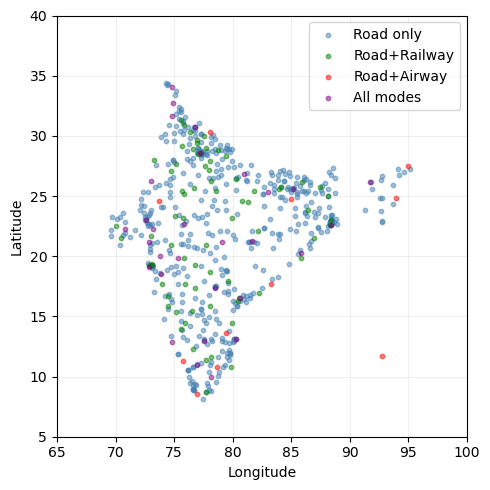

In [95]:
df = import_data(total_data_path)
air_df = import_data(airway_data_path)
rail_df = import_data(railway_data_path)
# fc_df = import_data(fc_data_path)
# df.info()
# air_df.info()
# rail_df.info()
# fc_df.info()
plot_cities(df, air_df, rail_df)

### Genetic Algorithm

In [179]:
generation_size = 200
reproduction_rate = 0.01
mutation_rate_pop = 0.5
mutation_rate_bit = 0.002
num_generations = 500

Step 1/4: Calculating physical distance matrix...
Step 2/4: Building transport cost matrix...
Step 3/4: Running Floyd Warshall algorithm... 


Step 4/4: Running genetic algorithm... : 100%|███████████████████| 500/500 [00:04<00:00, 108.99it/s]


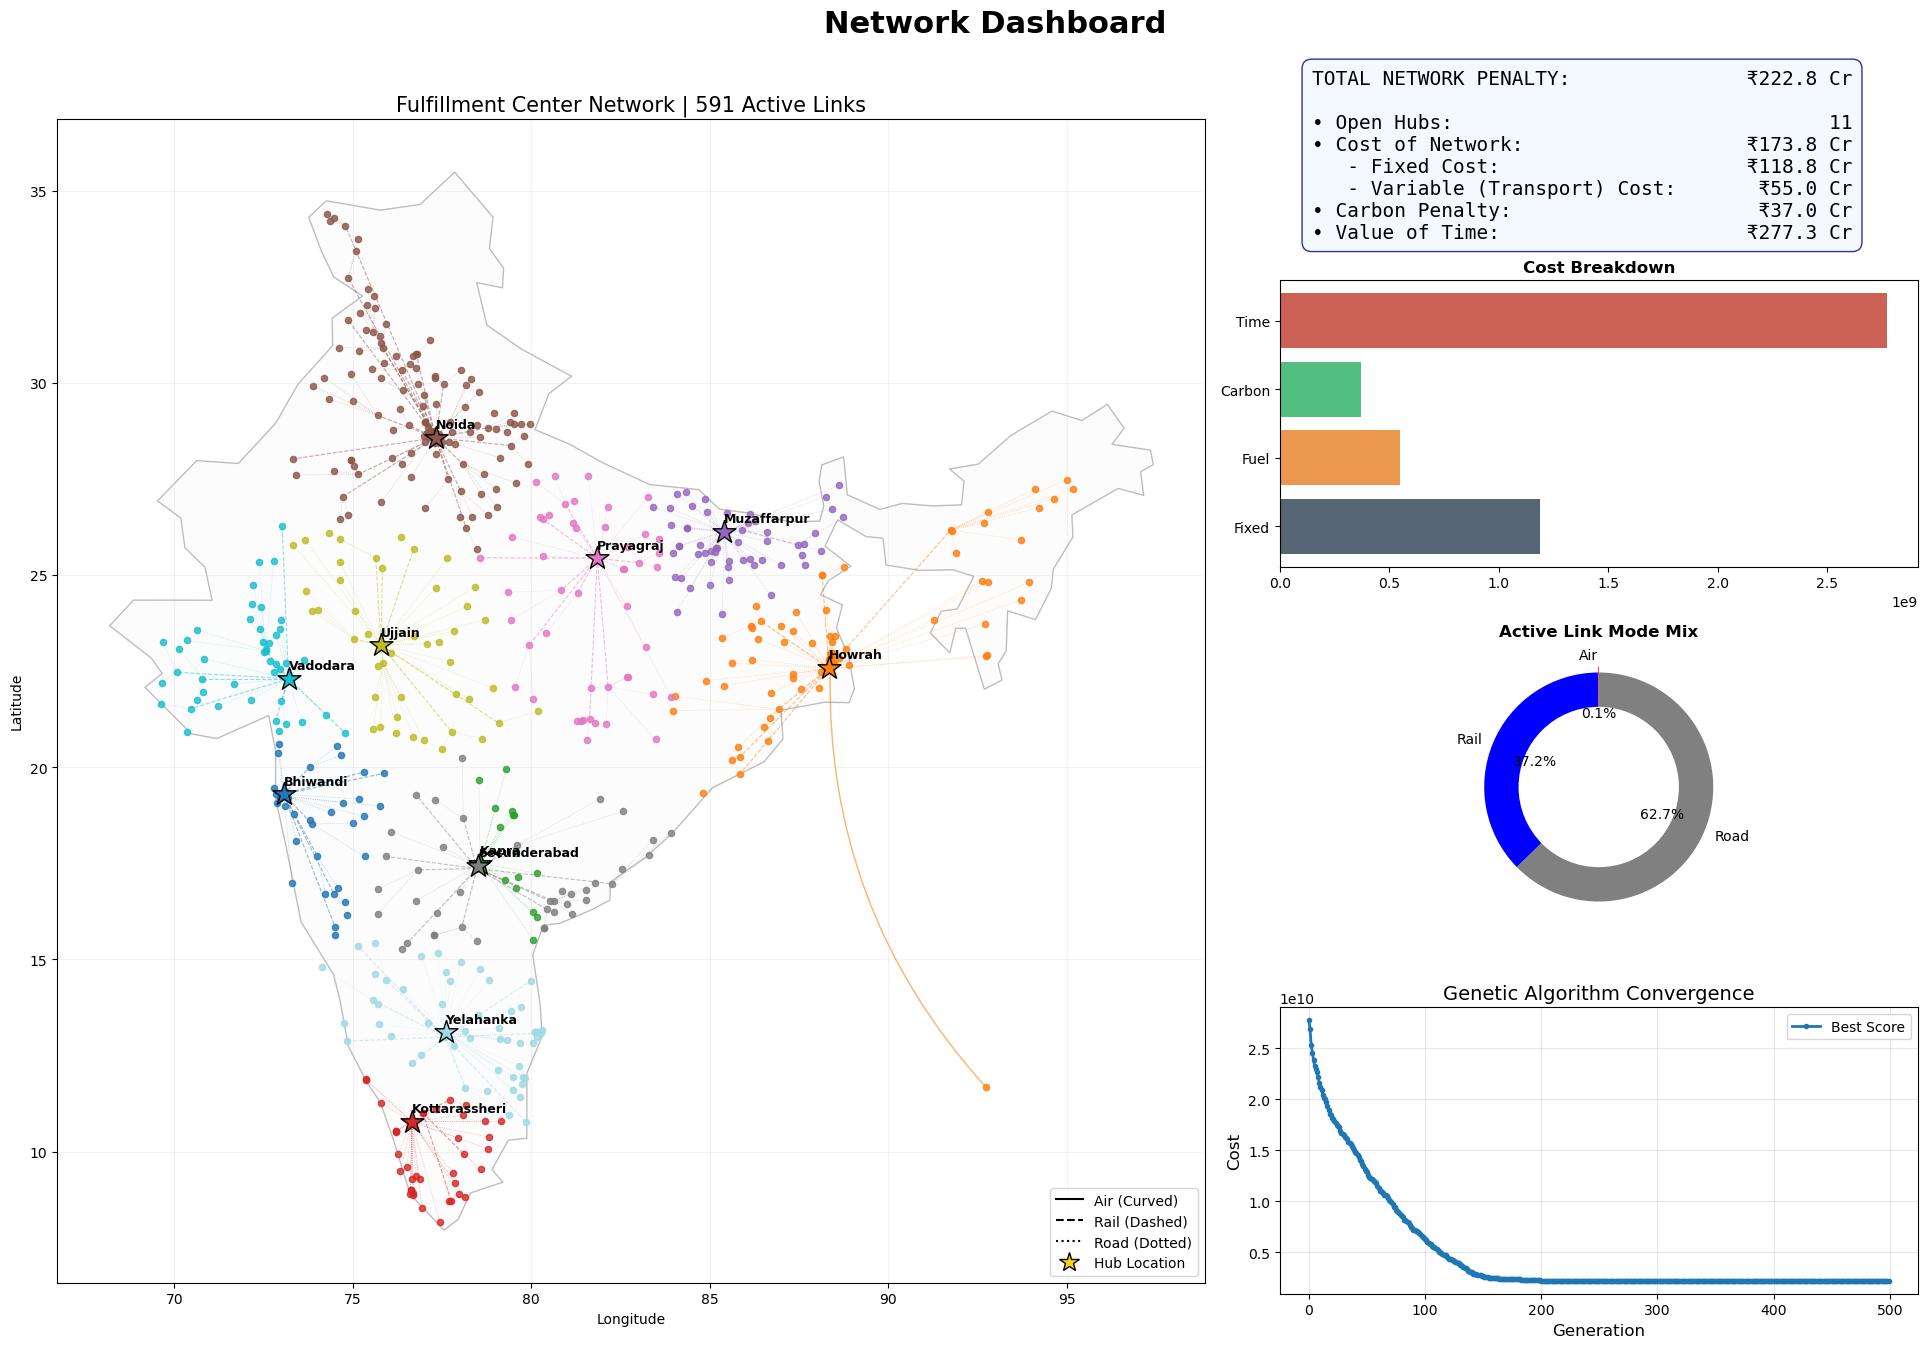

In [192]:
weights = {
    "fuel": 1,
    "carbon": 1,
    "time": 1,
    "fixed": 100,
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       transport_costs = transport_costs,
                       cost_components = cost_components,
                       df = df,
                       weights = weights)
show_dashboard(df, ga, transport_costs, cost_components, next_node, weights)

Step 1/4: Calculating physical distance matrix...
Step 2/4: Building transport cost matrix...
Step 3/4: Running Floyd Warshall algorithm... 


Step 4/4: Running genetic algorithm... : 100%|███████████████████| 500/500 [00:04<00:00, 101.56it/s]


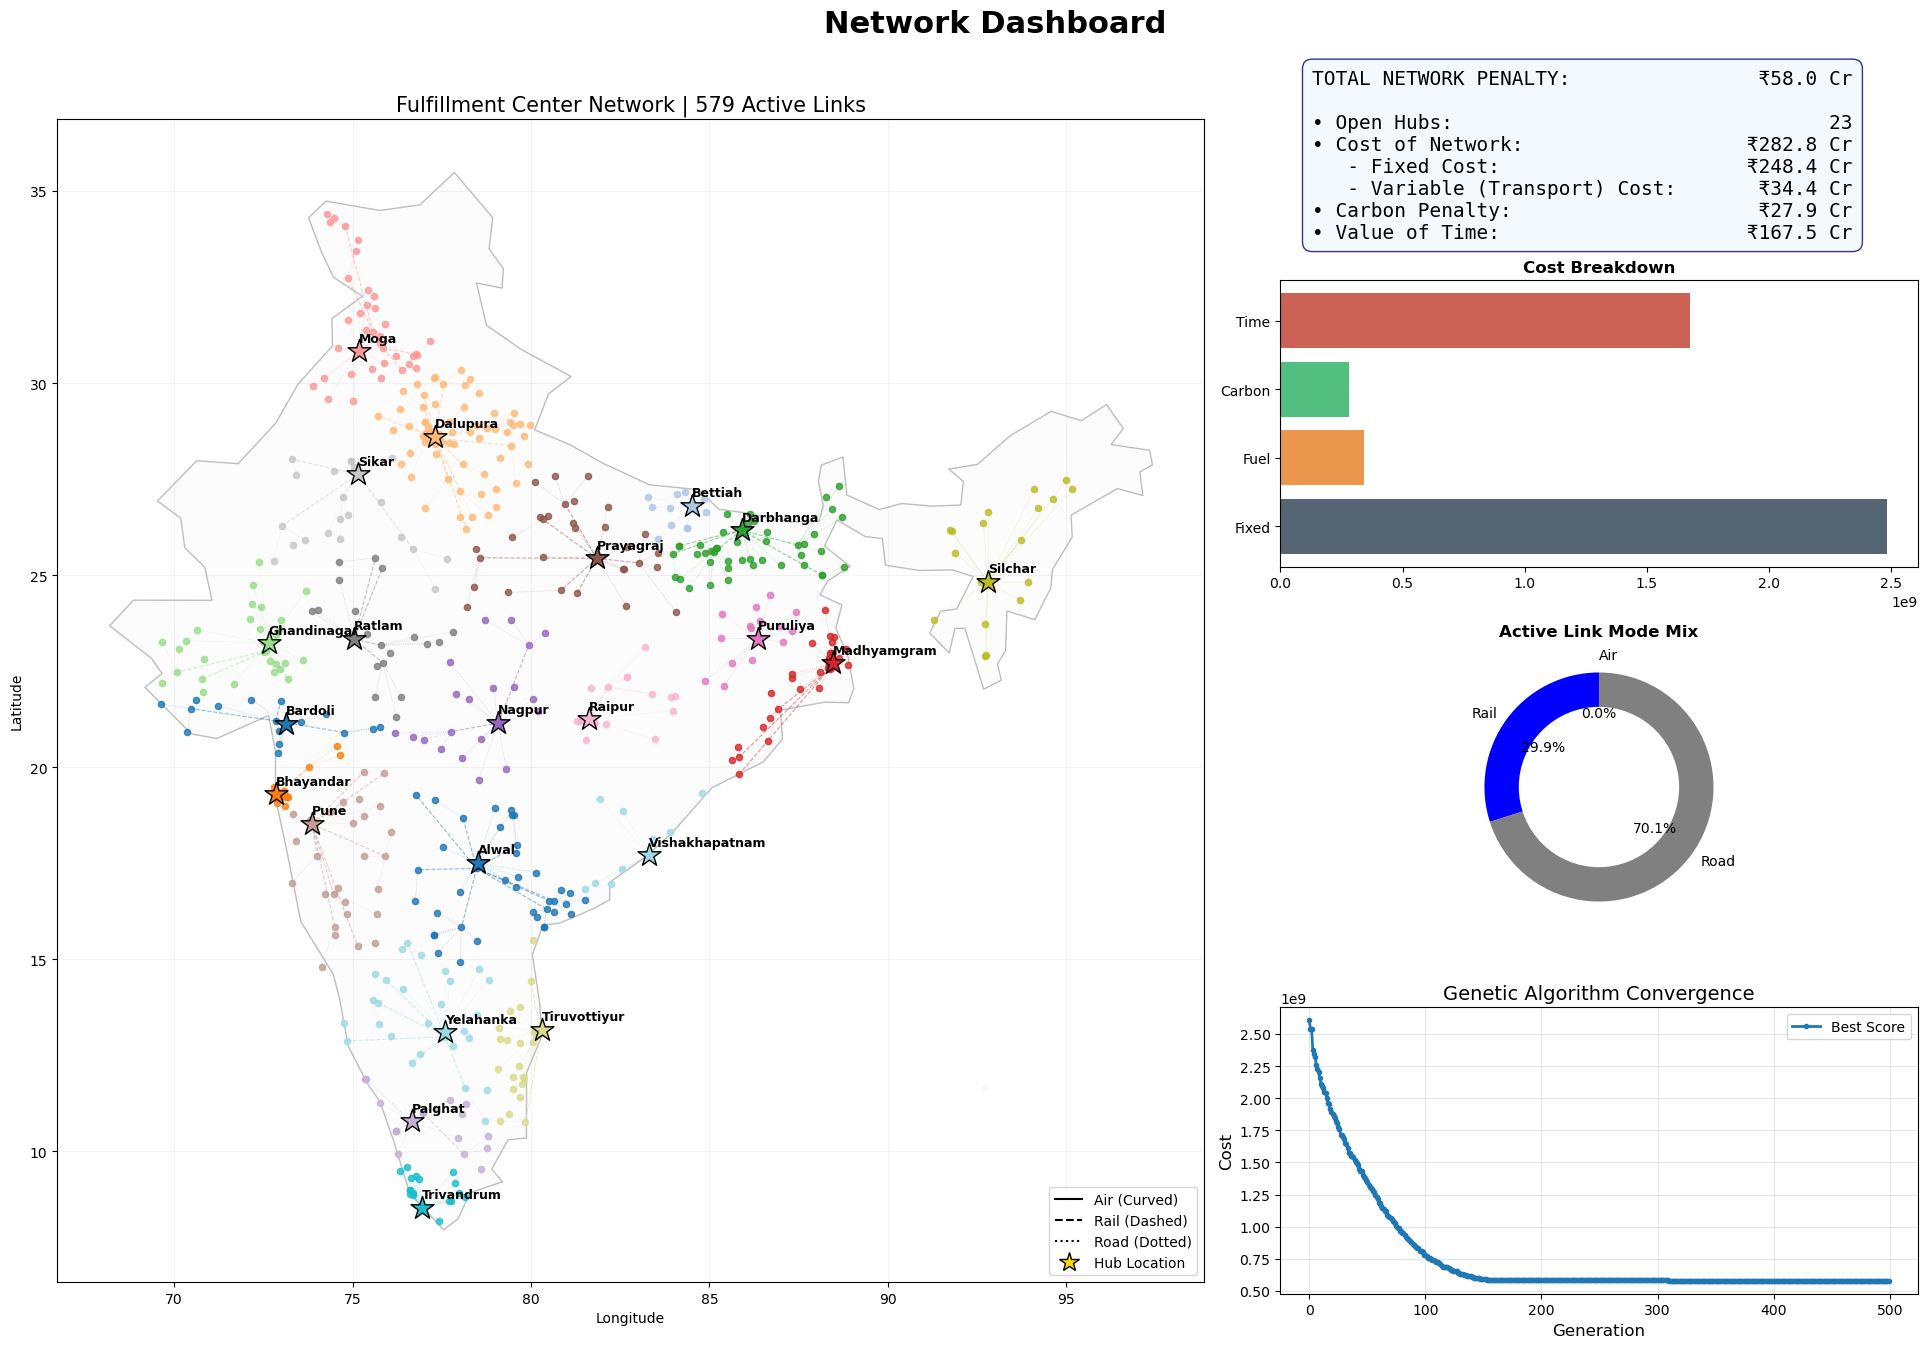

In [195]:
weights = {
    "fuel": 100,
    "carbon": 1,
    "time": 1.5,
    "fixed": 10,
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       transport_costs = transport_costs,
                       cost_components = cost_components,
                       df = df,
                       weights = weights)
show_dashboard(df, ga, transport_costs, cost_components, next_node, weights)

In [ ]:
weights = {
    "fuel": 1,
    "carbon": 1,
    "time": 1.5,
    "fixed": 10,
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       transport_costs = transport_costs,
                       cost_components = cost_components,
                       df = df)
show_dashboard(df, ga, transport_costs, cost_components, next_node, weights)

Step 1/4: Calculating physical distance matrix...
Step 2/4: Building transport cost matrix...
Step 3/4: Running Floyd Warshall algorithm... 
Convergence test: running 10 independent GA runs


Running independent trials: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:52<00:00,  5.24s/it]


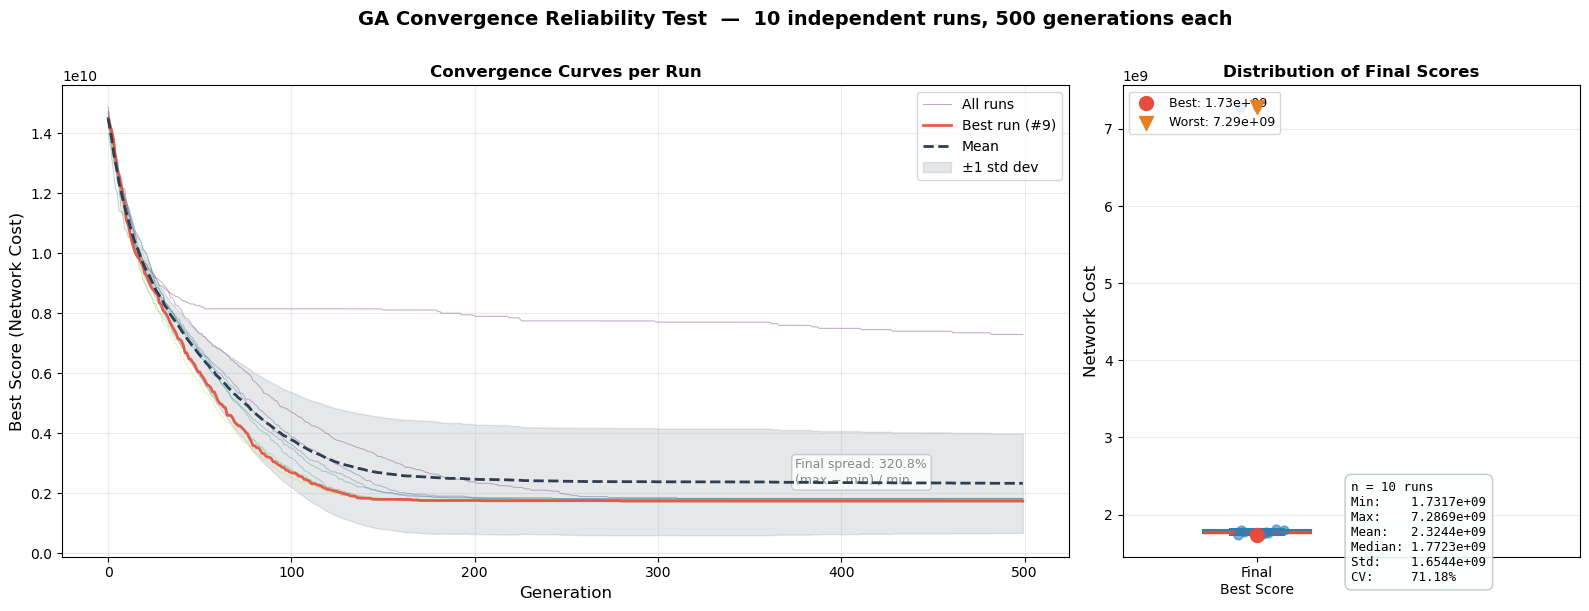


── Convergence verdict ─────────────────────────────────────
🔴  Poor — CV ≥ 15%. High variance. GA is not reliably converging.
    Coefficient of Variation: 71.18%
    Best run #9 scored 1.7317e+09
────────────────────────────────────────────────────────────



In [184]:
weights = {
    "fuel": 1,
    "carbon": 1,
    "time": 1,
    "fixed": 3,
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
conv_results = run_convergence_test(
    n_runs=10,
    generation_size=generation_size,
    reproduction_rate=reproduction_rate,
    mutation_rate_pop=mutation_rate_pop,
    mutation_rate_bit=mutation_rate_bit,
    num_generations=num_generations,
    df=df,
    transport_costs=transport_costs,
    cost_components=cost_components,
    weights = weights
)

plot_convergence_test(conv_results)

Step 1/4: Calculating physical distance matrix...
Step 2/4: Building transport cost matrix...
Step 3/4: Running Floyd Warshall algorithm... 
Convergence test: running 100 independent GA runs


Running independent trials: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [23:43<00:00, 14.24s/it]


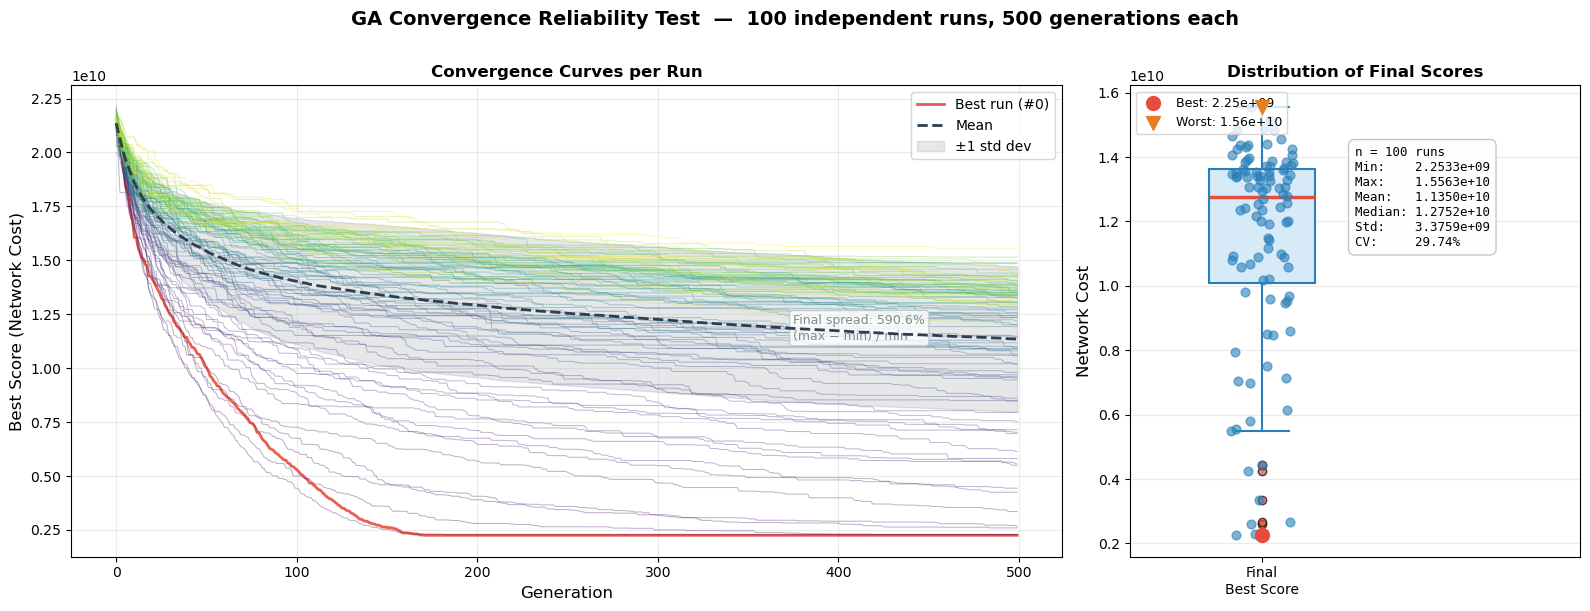


── Convergence verdict ─────────────────────────────────────
🔴  Poor — CV ≥ 15%. High variance. GA is not reliably converging.
    Coefficient of Variation: 29.74%
    Best run #0 scored 2.2533e+09
────────────────────────────────────────────────────────────



In [194]:
weights = {
    "fuel": 1,
    "carbon": 1,
    "time": 1.5,
    "fixed": 10,

}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
conv_results = run_convergence_test(
    n_runs=100,
    generation_size=generation_size,
    reproduction_rate=reproduction_rate,
    mutation_rate_pop=mutation_rate_pop,
    mutation_rate_bit=mutation_rate_bit,
    num_generations=num_generations,
    df=df,
    transport_costs=transport_costs,
    cost_components=cost_components,
    weights = weights
)

plot_convergence_test(conv_results)

In [ ]:
plot_convergence_test(conv_results)

In [ ]:
np.savez('solutions/sol_1_34_e9_111.npz', **ga)

Step 1/4: Calculating physical distance matrix...
Step 2/4: Building transport cost matrix...
Step 3/4: Running Floyd Warshall algorithm... 


Step 4/4: Running genetic algorithm... : 100%|███████████████████| 500/500 [00:04<00:00, 107.33it/s]


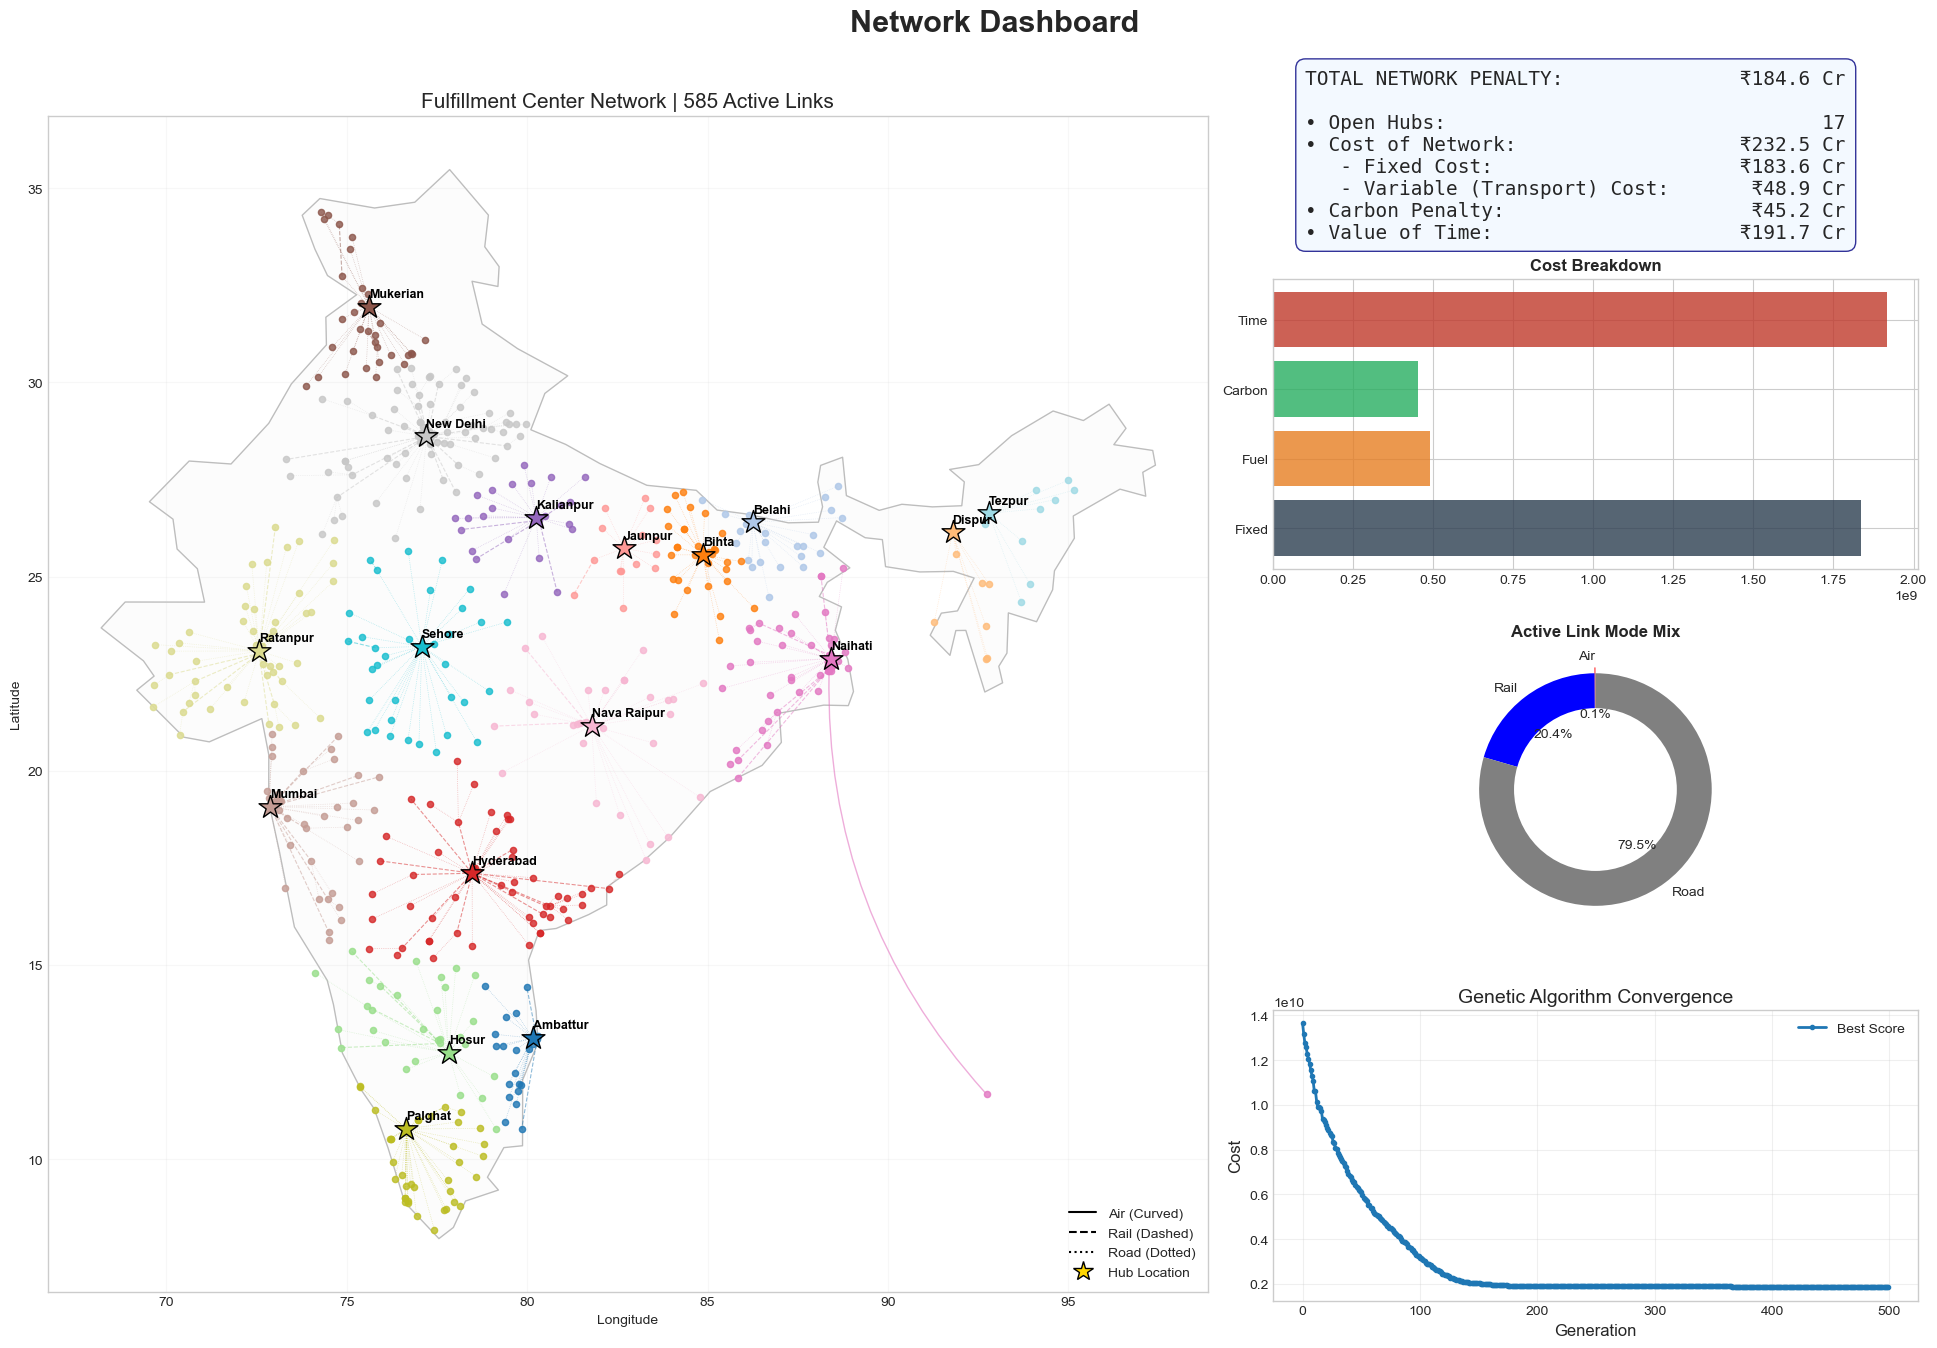

In [285]:
weights = {
    "fuel": 1,
    "carbon": 1,
    "time": 1.5,
    "fixed": 3
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       transport_costs = transport_costs,
                       cost_components = cost_components,
                       df = df,
                      weights = weights)
show_dashboard(df, ga, transport_costs, cost_components, next_node, weights)

In [ ]:
show_dashboard(df, ga, transport_costs, cost_components, next_node, weights)

Step 1/4: Calculating physical distance matrix...
Step 2/4: Building transport cost matrix...
Step 3/4: Running Floyd Warshall algorithm... 

Running 1000 independent GA trials...


Progress: 100%|███████████████████████████████████████████████| 1000/1000 [1:31:07<00:00,  5.47s/it]


ANALYSIS COMPLETE | 1000 runs | weights: 1/1/1
Avg warehouses: 11.3 ± 1.2
Avg cost: 1.91e+09 | Best: 1.83e+09

Rank   City                      Freq %     Count   
────────────────────────────────────────────────────────────
10     Prayagraj                   32.2%     322
4      Bangalore                   31.9%     319
599    Abbigeri                    21.9%     219
6      Hyderabad                   20.4%     204
20     Nagpur                      19.9%     199
5      Chennai                     19.7%     197
510    Yelahanka                   19.5%     195
241    Tiruvottiyur                18.6%     186
285    Secunderabad                18.2%     182
240    New Delhi                   17.9%     179
2      Mumbai                      17.0%     170
232    Malkajgiri                  16.8%     168
130    Ambattur                    15.3%     153
16     Kottarassheri               15.2%     152
62     Coimbatore                  15.1%     151

──────────────────────────────────────

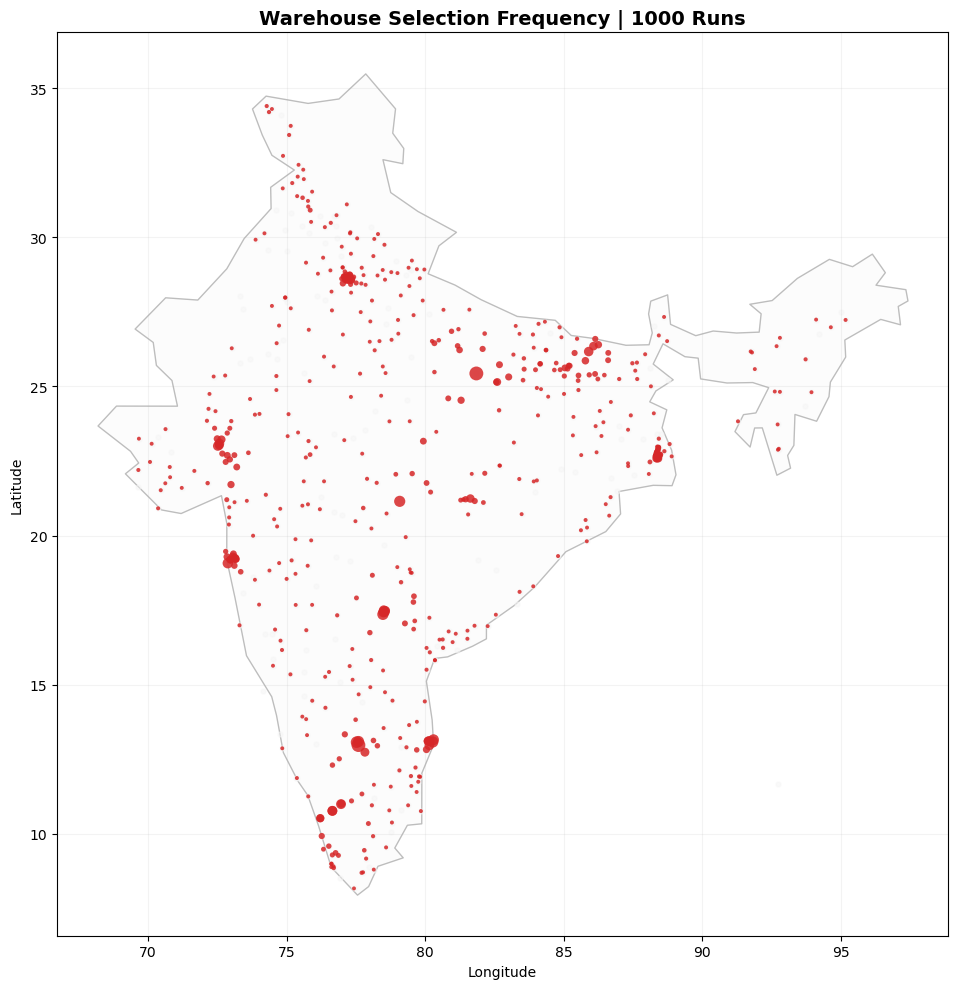

In [196]:
weights = {
    "fuel": 1,
    "carbon": 1,
    "time": 1,
    "fixed": 5,
}
generation_size = 200
reproduction_rate = 0.01
mutation_rate_pop = 0.5
mutation_rate_bit = 0.002
num_generations = 500

transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ans = run_frequency_analysis(
    n_runs=1000,
    generation_size=generation_size,
    reproduction_rate=reproduction_rate,
    mutation_rate_pop=mutation_rate_pop,
    mutation_rate_bit=mutation_rate_bit,
    num_generations=num_generations,
    df=df,
    transport_costs=transport_costs,
    cost_components=cost_components
)

In [275]:
pop = init_pop(count = 100000, sol_size = 602)

In [225]:
pop.shape

(100000, 602)

In [276]:
weights = {
    "fuel": 1,
    "carbon": 1,
    "time": 1.5,
    "fixed": 3,

}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)

Step 1/4: Calculating physical distance matrix...
Step 2/4: Building transport cost matrix...
Step 3/4: Running Floyd Warshall algorithm... 


In [277]:
costs = calc_network_cost_batch(df= df,
                      solutions = pop,
                      transport_costs = transport_costs,
                      cost_components = cost_components,
                      fixed_weight = fixed_weight)

In [228]:
fixed_weight = weights['fixed']/sum(weights.values())

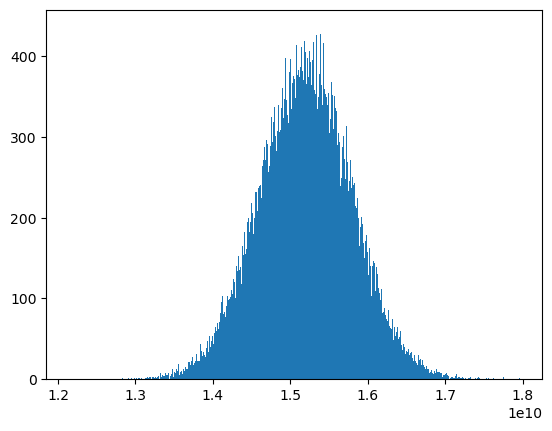

In [229]:
plt.hist(costs, bins = 1000)
plt.show()

In [231]:
def plot_costs_hist(costs, title="Distribution of Network Costs"):
    costs = np.asarray(costs)

    # Freedman–Diaconis rule for optimal bin width
    q25, q75 = np.percentile(costs, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr / (len(costs) ** (1/3))
    
    if bin_width > 0:
        bins = int(np.ceil((costs.max() - costs.min()) / bin_width))
    else:
        bins = 50  # fallback

    mean_val = costs.mean()
    median_val = np.median(costs)

    plt.figure(figsize=(10, 6))

    plt.hist(costs, bins=bins, alpha=0.75)

    # Mean and median lines
    plt.axvline(mean_val, linestyle='--', linewidth=2,
                label=f"Mean: {mean_val:,.2f}")
    plt.axvline(median_val, linestyle='-', linewidth=2,
                label=f"Median: {median_val:,.2f}")

    # Labels and formatting
    plt.title(title, fontsize=16, pad=15)
    plt.xlabel("Network Cost", fontsize=13)
    plt.ylabel("Frequency", fontsize=13)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

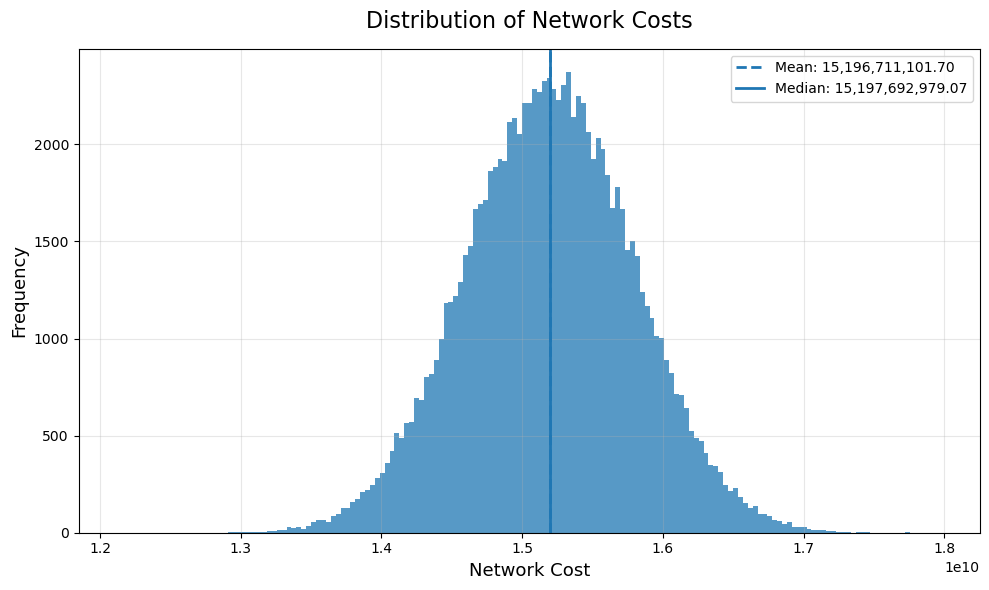

In [232]:
plot_costs_hist(costs)

In [239]:
conv_results = run_convergence_test(
    n_runs=100,
    generation_size=generation_size,
    reproduction_rate=reproduction_rate,
    mutation_rate_pop=mutation_rate_pop,
    mutation_rate_bit=mutation_rate_bit,
    num_generations=num_generations,
    df=df,
    transport_costs=transport_costs,
    cost_components=cost_components,
    weights = weights
)

Convergence test: running 100 independent GA runs


Running independent trials: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:43<00:00,  4.64s/it]


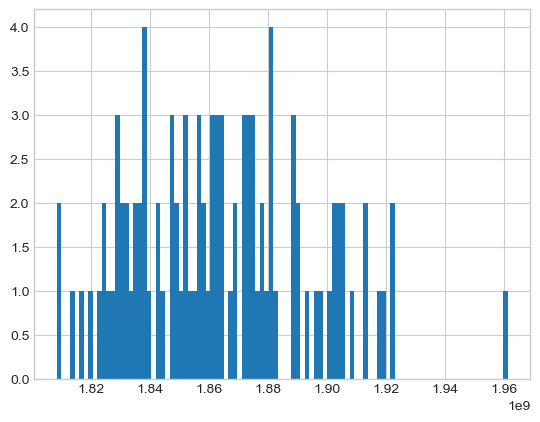

In [252]:
plt.hist(conv_results['final_scores'], bins = 100)
plt.show()

/var/folders/cx/b6xsqnx15dx__7p9ls22r_fr0000gn/T/ipykernel_97435/2759403948.py:82: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  means.append(float(top10_cost))


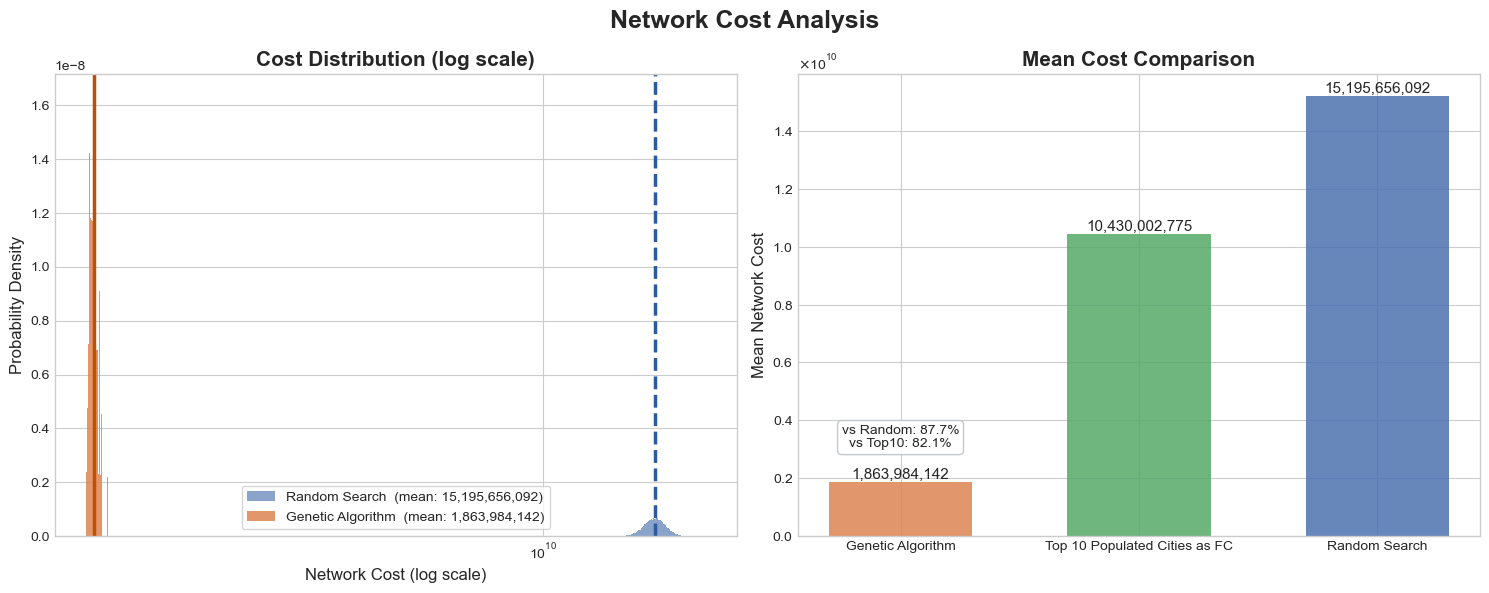

In [290]:
plot_cost_analysis(random_costs = costs, ga_costs = conv_results['final_scores'], top10_cost = top_cost)

In [272]:
def plot_cost_analysis(random_costs, ga_costs=None, top10_cost=None,
                       labels=("Random Search", "Genetic Algorithm", "Top 10 Populated Cities as FC"),
                       title="Network Cost Analysis"):

    plt.style.use('seaborn-v0_8-whitegrid')

    random_costs = np.asarray(random_costs)

    if ga_costs is not None:
        ga_costs = np.asarray(ga_costs)
        combined = np.concatenate([random_costs, ga_costs])
    else:
        combined = random_costs

    # ── log safety cleaning ───────────────────────────────────
    combined = combined[np.isfinite(combined)]
    combined = combined[combined > 0]

    bins = np.histogram_bin_edges(np.log10(combined), bins='fd')
    bins = 10**bins

    colors = {
        "random": "#4C72B0",
        "ga": "#DD8452",
        "top10": "#55A868",
        "random_mean": "#2C5AA0",
        "ga_mean": "#C44E00"
    }

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ── LEFT PANEL ────────────────────────────────────────────
    axes[0].hist(random_costs,
                 bins=bins,
                 density=True,
                 alpha=0.65,
                 color=colors["random"],
                 edgecolor='none',
                 label=f"{labels[0]}  (mean: {random_costs.mean():,.0f})")

    axes[0].axvline(random_costs.mean(),
                    color=colors["random_mean"],
                    linestyle='--',
                    linewidth=2.5)

    if ga_costs is not None:

        axes[0].hist(ga_costs,
                     bins=bins,
                     density=True,
                     alpha=0.85,
                     color=colors["ga"],
                     edgecolor='none',
                     label=f"{labels[1]}  (mean: {ga_costs.mean():,.0f})")

        axes[0].axvline(ga_costs.mean(),
                        color=colors["ga_mean"],
                        linestyle='-',
                        linewidth=2.5)

    axes[0].set_xscale('log')
    axes[0].set_title("Cost Distribution (log scale)", fontsize=15, weight='bold')
    axes[0].set_xlabel("Network Cost (log scale)", fontsize=12)
    axes[0].set_ylabel("Probability Density", fontsize=12)
    axes[0].legend(frameon=True)

    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, 2))

    # ── RIGHT PANEL ───────────────────────────────────────────
    if ga_costs is not None:

        random_mean = random_costs.mean()
        ga_mean = ga_costs.mean()

        bar_labels = [labels[0], labels[1]]
        means = [random_mean, ga_mean]
        bar_colors = [colors["random"], colors["ga"]]

        if top10_cost is not None:
            bar_labels.append(labels[2])
            means.append(float(top10_cost))
            bar_colors.append(colors["top10"])

        # ⭐ sort by cost (ascending)
        order = np.argsort(means)
        means = list(np.array(means)[order])
        bar_labels = list(np.array(bar_labels)[order])
        bar_colors = list(np.array(bar_colors)[order])

        bars = axes[1].bar(bar_labels,
                           means,
                           color=bar_colors,
                           alpha=0.85,
                           width=0.6)

        # value labels
        for bar, val in zip(bars, means):
            axes[1].text(bar.get_x() + bar.get_width()/2,
                         val,
                         f"{val:,.0f}",
                         ha='center',
                         va='bottom',
                         fontsize=11)

        # ⭐ GA comparison annotation
        if labels[1] in bar_labels:
            ga_idx = bar_labels.index(labels[1])
            ga_val = means[ga_idx]

            comparisons = []

            if labels[0] in bar_labels:
                rand_val = means[bar_labels.index(labels[0])]
                pct = (rand_val - ga_val) / rand_val * 100
                comparisons.append(f"vs Random: {pct:.1f}%")

            if top10_cost is not None and labels[2] in bar_labels:
                top_val = means[bar_labels.index(labels[2])]
                pct = (top_val - ga_val) / top_val * 100
                comparisons.append(f"vs Top10: {pct:.1f}%")

            axes[1].annotate(
                "\n".join(comparisons),
                xy=(bars[ga_idx].get_x() + bars[ga_idx].get_width()/2, ga_val),
                xytext=(0, 25),
                textcoords="offset points",
                ha='center',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3',
                          fc='white',
                          ec='#bdc3c7',
                          alpha=0.9)
            )

        axes[1].set_title("Mean Cost Comparison", fontsize=15, weight='bold')
        axes[1].set_ylabel("Mean Network Cost", fontsize=12)
        axes[1].yaxis.set_major_formatter(formatter)

    else:
        axes[1].axis('off')

    fig.suptitle(title, fontsize=18, weight='bold')

    plt.tight_layout()
    plt.show()

In [286]:
highest_pop = np.zeros(602)
highest_pop[:17] = 1
highest_pop = np.array([highest_pop])

In [287]:
top_cost = calc_network_cost_batch(df= df,
                      solutions = np.array([highest_pop]),
                      transport_costs = transport_costs,
                      cost_components = cost_components,
                      fixed_weight = fixed_weight)

In [288]:
top_cost

array([1.04300028e+10])

In [289]:
costs

array([1.49752822e+10, 1.51389260e+10, 1.56581656e+10, ...,
       1.56326673e+10, 1.59739651e+10, 1.54092273e+10])